In [ ]:
%load_ext autoreload
%autoreload 2

import json
import warnings 
from pathlib import Path
from collections import defaultdict
from typing import Optional

from tqdm import tqdm

import jax
import jax.numpy as jnp
from jax import jit, hessian, grad
jax.config.update("jax_enable_x64", True)

import numpy as np 
import pandas as pd

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error as mse

from source.visuals import PARAMS, plot_mtx
from source.prob_functions import (
    w_sample, 
    predict_std,
    update_beta_e,
    update_gamma_w,
)
from source.model_functionality import (
    init_weights
    get_fw_hadamard_mtx,
    get_ww_hadamard_mtx,
    update_weights,
    predict_score,
    prepare_system,
    check_zero_cols,
)
from source.matrix_operations import (
    khatri_rao_row, 
    block_diag, 
    vec2ten3, 
    ten3tovec, 
    factors2vec,
)

from source.evaluation import rmse, nll, l2_gb_loss, norm_frob
from source.data_functions import load_transform_data, get_batches
from source.features import PPFeature, PPNFeature, RBFFeature, FFeature, prepare_fmap
from source.general_functions import update_results_dict, extend_results_dict, create_dir_if_not_exists, query_df, check_nan
from source.optimization import adam_update, gd_update, full_grid

warnings.filterwarnings("ignore")
sns.set_theme()

DATA_DIR = Path('./data')

In [17]:
import jax
import jax.numpy as jnp
from jax import grad, jit, random
from functools import partial

# Create a toy dataset: y = sin(2πx) + noise
key = random.PRNGKey(42)
X = jnp.linspace(-1, 1, 100).reshape(-1, 1)
true_y = jnp.sin(2 * jnp.pi * X)
y = true_y + 0.1 * random.normal(key, shape=X.shape)

# Model architecture: 1-hidden-layer ReLU NN
def relu(x):
    return jnp.maximum(0, x)

def predict(params, x):
    W1, b1, W2, b2 = params
    h = relu(x @ W1 + b1)
    out = h @ W2 + b2
    return out

# MSE Loss
def loss_fn(params, x, y):
    preds = predict(params, x)
    return jnp.mean((preds - y) ** 2)

# SGD update
@jit
def update(params, grads, lr):
    return [(w - lr * dw) for w, dw in zip(params, grads)]

# Initialization
def init_params(key, in_dim, hidden_dim, out_dim):
    k1, k2 = random.split(key)
    W1 = random.normal(k1, (in_dim, hidden_dim)) * 0.1
    b1 = jnp.zeros((1, hidden_dim))
    W2 = random.normal(k2, (hidden_dim, out_dim)) * 0.1
    b2 = jnp.zeros((1, out_dim))
    return [W1, b1, W2, b2]

def train(
    key, 
    X, 
    y, 
    hidden_dim=10, 
    lr=0.01, 
    n_epochs=1000, 
    k_decay=200, 
    decay_factor=0.5
):
    params = init_params(key, X.shape[1], hidden_dim, 1)
    loss_history = []

    for epoch in range(n_epochs):
        # Apply learning rate decay every k_decay epochs
        lr_current = lr * (decay_factor ** (epoch // k_decay))

        grads = grad(loss_fn)(params, X, y)
        grad_norm = sum([jnp.linalg.norm(g) for g in grads])
        if grad_norm < 1e-5:
            print(f"Stationary point reached at epoch {epoch}, gradient norm: {grad_norm:.2e}")
            break

        params = update(params, grads, lr_current)

        if epoch % 5000 == 0:
            l = loss_fn(params, X, y)
            loss_history.append(l)
            print(f"Epoch {epoch}: loss = {l:.4f}, lr = {lr_current:.5f}, grad_norm = {grad_norm:.2e}")

    return params


# Run training
trained_params = train(key, X, y, hidden_dim=200, lr=0.2, n_epochs=50000, k_decay=10000)


Epoch 0: loss = 0.4576, lr = 0.20000, grad_norm = 4.80e-01
Epoch 5000: loss = 0.2182, lr = 0.20000, grad_norm = 2.16e+00
Epoch 10000: loss = 0.1556, lr = 0.10000, grad_norm = 2.16e+00
Epoch 15000: loss = 0.1904, lr = 0.10000, grad_norm = 3.47e+00
Epoch 20000: loss = 0.1030, lr = 0.05000, grad_norm = 3.48e+00
Epoch 25000: loss = 0.1172, lr = 0.05000, grad_norm = 4.34e+00
Epoch 30000: loss = 0.0420, lr = 0.02500, grad_norm = 4.38e+00
Epoch 35000: loss = 0.0180, lr = 0.02500, grad_norm = 1.58e-02
Epoch 40000: loss = 0.0140, lr = 0.01250, grad_norm = 7.30e-03
Epoch 45000: loss = 0.0132, lr = 0.01250, grad_norm = 6.40e-03


# Debug Sandbox:

## Vanilla model 2.0:

In [2]:
from source.data_functions import scale_data

def generate_random_x(n_samples, d_dim, min_v=-4, max_v=4, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    x = rs.uniform(min_v, max_v, (n_samples, d_dim))
    if sort_x:
        x = np.sort(x, axis=0)
    return x
    
def generate_x2_data(n_samples, d_dim, min_v=-4, max_v=4, std_err=3, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    x = generate_random_x(n_samples, d_dim, min_v, max_v, seed, sort_x)
    e = rs.normal(0.0, std_err, (n_samples,))
    y_true = (x**2).sum(axis=1)
    y = y_true + e
    return x, y, y_true

def l2_reg_loss_vanilla(w_vec, x, y, fmap, gamma_w, beta_e):
    scores = predict_score_vanilla(x, w_vec, fmap)
    return 0.5*(beta_e*jnp.sum((y - scores)**2) + gamma_w*(w_vec * w_vec).sum())

def predict_score_vanilla(x, w_vec, fmap):
    design_mtx = get_design_mtx(x, fmap)
    return jnp.real(design_mtx.dot(w_vec))

def ls_sol(x, y, fmap, gamma_w, beta_e):
    alpha = gamma_w / beta_e
    F_mtx = get_design_mtx(x, fmap)
    A_mtx = F_mtx.T.conj().dot(F_mtx) + alpha*jnp.eye(F_mtx.shape[1])
    b = F_mtx.T.conj().dot(y)
    return jnp.linalg.solve(A_mtx, b)

def adam_sol(w_vec, x, y, fmap, n_epoch, gamma_w, beta_e, grad_w, lr, bs):
    m = jnp.zeros_like(w_vec)
    v = jnp.zeros_like(m)
    t = 0  # Time step
    grad_norm_tracker, loss_tracker = list(), list()
    for ep in range(n_epoch):
        for x_batch, y_batch in get_batches(x, y, batch_size=bs):
            dw = grad_w(w_vec, x_batch, y_batch, fmap, gamma_w, beta_e)
            #w_vec = gd_update(w_vec, dw, lr)
            w_vec, m, v, t = adam_update(w_vec, dw, m, v, t, lr)
        loss_tracker.append((ep, l2_reg_loss_vanilla(w_vec, x, y, fmap, gamma_w, beta_e).item()))
        grad_norm_tracker.append((ep, norm_frob(grad_w(w_vec, x, y, fmap, gamma_w, beta_e)).item()))
    return w_vec, grad_norm_tracker, loss_tracker

def get_design_mtx(x, fmap):
    _, d_dim = x.shape
    design_mtx = fmap(x[:, 0], None)
    for k in range(1, d_dim):
        design_mtx = khatri_rao_row(fmap(x[:, k], None), design_mtx)
    return design_mtx

def test_get_design_mtx():
    x = jnp.array([[1, 2, 3], [2, 3, 4], [3, 4, 5]])
    fmap, _ = prepare_fmap(PPFeature(), 2, False)

    actual = get_design_mtx(x, fmap)
    expected = jnp.array(
        [
            [1, 1, 2, 2, 3, 3, 6, 6], 
            [1, 2, 3, 6, 4, 8, 12, 24], 
            [1, 3, 4, 12, 5, 15, 20, 60],
        ]
    )
    print(jnp.linalg.norm(actual-expected))

test_get_design_mtx()

0.0


##### Adam:

In [3]:
N_SAMPLES = 100
BETA_E = 1.0
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' # std / minmax
QUANT, MAX_PARAMS = False, 5000

FMAP = PPNFeature()

d_dim_list = [2, 4, 8, 10, 12, 16, 20, 24, 36]
m_order_list = [2, 4, 8, 10, 12, 16, 20, 24, 36]
gamma_w_list = [1e-9, 1e-6, 1e-3, 1e-1, 1e0]

TRAIN = False
TRAIN_METHOD = 'adam' 
N_EPOCH = 200
LR = 5e-2
BS = 50

SAVE_DIR = Path(f'./artifacts/map_search/no_td/{TRAIN_METHOD}/training_artifacts/')
create_dir_if_not_exists(SAVE_DIR)

if TRAIN:
    grad_w = grad(l2_reg_loss_vanilla, argnums=0)
    res_list = []
    for d_dim in d_dim_list:
        x, y, y_true = generate_x2_data(N_SAMPLES, d_dim, std_err=np.sqrt(1/BETA_E), seed=13)
        x, _, y, _ = scale_data(x, jnp.empty_like(x), y, jnp.empty_like(y), TRANSFORM_X, TRANSFORM_Y, SCALER)
        x, y = map(jnp.array, [x, y])
        #print(f'X stats (scaler: "{SCALER}"): Mean={x.mean(axis=0)}, Std={x.std(axis=0)}, Min={x.min()}, Max={x.max()}')
        for m_order in m_order_list:
            P = m_order**d_dim
            if P <= MAX_PARAMS:
                fmap, dtype = prepare_fmap(FMAP, m_order, QUANT)
                for gamma_w in gamma_w_list:
                    print(d_dim, m_order, gamma_w)
                    # Get Solution:
                    w_vec = jnp.array(np.random.RandomState(13).randn(P))
                    w_map, grad_norm_tracker, loss_tracker = adam_sol(w_vec, x, y, fmap, N_EPOCH, gamma_w, BETA_E, grad_w, LR, BS)
                    # Grad norm:
                    gw = grad_w(w_map, x, y, fmap, gamma_w, BETA_E)
                    norm_grad = norm_frob(gw)
                    # Loss value:
                    loss_value = l2_reg_loss_vanilla(w_map, x, y, fmap, gamma_w, BETA_E)
                    # Solution norm:
                    w_norm = norm_frob(w_map)
                    # Hessian, Cov, Cholesky:
                    F_mtx = get_design_mtx(x, fmap)
                    hw_hand = BETA_E*F_mtx.T.conj().dot(F_mtx) + gamma_w*jnp.eye(F_mtx.shape[1])
                    try:
                        w_cholesky = np.linalg.cholesky(hw_hand)
                        w_cholesky = np.linalg.pinv(w_cholesky.T)
                        w_cov = w_cholesky.dot(w_cholesky.T)
                        cov_symm = (w_cov == w_cov.T).all()
                    except Exception as e:
                        cov_symm = None
                        print(e)

                    res_list.append(
                        (
                            d_dim, m_order, gamma_w, norm_grad, loss_value, w_norm, cov_symm, N_SAMPLES, P, BETA_E, SCALER, FMAP.name,
                            grad_norm_tracker, loss_tracker,
                        )
                    )
    cols = ['d_dim', 'm_order', 'gamma_w', 'norm_grad', 'loss', 'w_norm', 'cov_symm', 'N', 'P', 'beta_e', 'data_scale', 'fmap', 'norm_grad_list', 'loss_list']
    df = pd.DataFrame(res_list, columns=cols)
    df.to_csv(SAVE_DIR / 'adam.csv')

In [5]:
df = pd.read_csv(SAVE_DIR / 'adam.csv', index_col=0)

In [9]:
query_df(df, dict(gamma_w=1e-6))

,d_dim,m_order,gamma_w,norm_grad,loss,w_norm,cov_symm,N,P,beta_e,data_scale,fmap,norm_grad_list,loss_list
1,2,2,0.000001,0.172178,6.042959,3.269869,True,100,4,1.0,std,ppnf,"[(0, 34.61149074826322), (1, 29.62942088141000...","[(0, 37.738892324428534), (1, 32.3353420684034..."
6,2,4,0.000001,0.354420,0.792792,5.399419,True,100,16,1.0,std,ppnf,"[(0, 43.14298682229547), (1, 34.83910482938773...","[(0, 50.21965737438818), (1, 37.38385948486365..."
11,2,8,0.000001,0.207797,0.649436,9.298754,True,100,64,1.0,std,ppnf,"[(0, 38.45072800106779), (1, 28.31389643897376...","[(0, 53.29296553270681), (1, 38.23780718630946..."
16,2,10,0.000001,0.524935,0.676188,9.768662,True,100,100,1.0,std,ppnf,"[(0, 30.498781367428464), (1, 22.8565186849447...","[(0, 41.4637303471464), (1, 31.572847622731405..."
21,2,12,0.000001,0.329760,0.690745,11.429296,True,100,144,1.0,std,ppnf,"[(0, 32.59262417997158), (1, 23.3880164062209)...","[(0, 41.12277724586327), (1, 27.98351416879170..."
26,2,16,0.000001,0.584765,0.643040,15.717280,True,100,256,1.0,std,ppnf,"[(0, 48.75704723699023), (1, 37.6942563772864)...","[(0, 67.91698712169574), (1, 45.32653723384852..."
31,2,20,0.000001,0.525419,0.546710,19.966567,True,100,400,1.0,std,ppnf,"[(0, 30.193901824330712), (1, 21.3287497593426...","[(0, 35.107142475164494), (1, 26.1600781510034..."
36,2,24,0.000001,0.466891,0.463982,23.292684,True,100,576,1.0,std,ppnf,"[(0, 19.649146771503837), (1, 11.8839932059421...","[(0, 12.035880517685353), (1, 7.47626796836885..."
41,2,36,0.000001,0.676104,0.440388,36.471794,True,100,1296,1.0,std,ppnf,"[(0, 25.971267953960098), (1, 17.9112148640899...","[(0, 31.04941386420639), (1, 23.36812153048673..."
46,4,2,0.000001,0.271272,0.460364,6.016461,True,100,16,1.0,std,ppnf,"[(0, 51.77237277397094), (1, 41.83078262243524...","[(0, 60.83035412106582), (1, 46.55860356948271..."


X stats (scaler: "std"): Mean=[-3.55271368e-17 -7.10542736e-17], Std=[1. 1.], Min=-1.543912976035811, Max=1.8844692403727816

Loss: 6.4810e-01; Norm grad: 0.2578123758479705; Norm diff hess: 0.0

W: Min=-2.7e+00, Max=2.4e+00, Mean=-5.3e-02

Order 1. Cholesky -> Inverse -> Covariance matrix
Is Covariance Matrix Symmetric? True


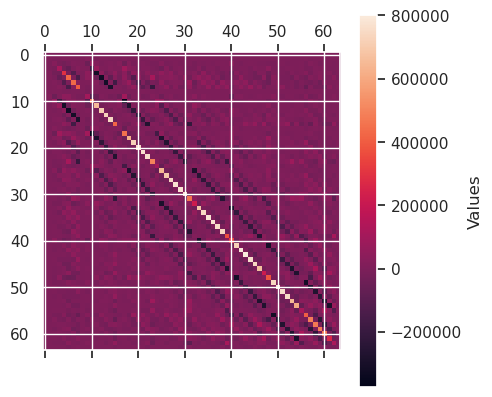

In [353]:
N_SAMPLES = 100
BETA_E = 1.0
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' # std / minmax
QUANT = False

d_dim, m_order = 2, 8
x, y, y_true = generate_x2_data(N_SAMPLES, d_dim, std_err=np.sqrt(1/BETA_E), seed=13)
x, _, y, _ = scale_data(x, jnp.empty_like(x), y, jnp.empty_like(y), TRANSFORM_X, TRANSFORM_Y, SCALER)
x, y = map(jnp.array, [x, y])
print(f'X stats (scaler: "{SCALER}"): Mean={x.mean(axis=0)}, Std={x.std(axis=0)}, Min={x.min()}, Max={x.max()}')

FMAP = PPNFeature()
gamma_w = 1e-6
fmap, dtype = prepare_fmap(FMAP, m_order, QUANT)
N_EPOCH = 200
LR = 5e-2
BS = 50

grad_w = grad(l2_reg_loss_vanilla, argnums=0)
w_vec = jnp.array(np.random.RandomState(13).randn(m_order**d_dim))
w_map, grad_norm_tracker, loss_tracker = adam_sol(w_vec, x, y, fmap, N_EPOCH, gamma_w, BETA_E, grad_w, LR, BS)

g_w = grad_w(w_map, x, y, fmap, gamma_w, BETA_E)

hess_f = hessian(l2_reg_loss_vanilla, argnums=0)
hw = hess_f(w_map, x, y, fmap, gamma_w, BETA_E)

F_mtx = get_design_mtx(x, fmap)
hw_hand = BETA_E*F_mtx.T.conj().dot(F_mtx) + gamma_w*jnp.eye(F_mtx.shape[1])

loss = l2_reg_loss_vanilla(w_map, x, y, fmap, gamma_w, BETA_E)
norm_grad = jnp.linalg.norm(g_w)
norm_diff_hess = jnp.linalg.norm(hw - hw_hand)
print(f"\nLoss: {loss:.4e}; Norm grad: {norm_grad}; Norm diff hess: {norm_diff_hess}")
print(f'\nW: Min={w_map.min():.1e}, Max={w_map.max():.1e}, Mean={w_map.mean():.1e}')

print('\nOrder 1. Cholesky -> Inverse -> Covariance matrix')
w_cholesky = np.linalg.cholesky(hw)
w_cholesky = np.linalg.pinv(w_cholesky.T)
w_cov = w_cholesky.dot(w_cholesky.T)
print('Is Covariance Matrix Symmetric?', (w_cov == w_cov.T).all())

plot_mtx(w_cov, '')

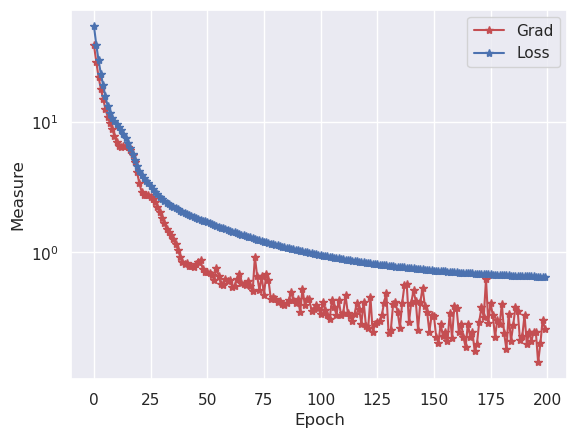

In [354]:
plt.plot([v[0] for v in grad_norm_tracker], [v[1] for v in grad_norm_tracker], '-*r', label='Grad')
plt.plot([v[0] for v in loss_tracker], [v[1] for v in loss_tracker], '-*b', label='Loss')
plt.legend()
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Measure');

##### Least Squares:

In [10]:
N_SAMPLES = 100
BETA_E = 1.0
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' # std / minmax
QUANT, MAX_PARAMS = False, 5000

FMAP = PPNFeature()

d_dim_list = [2, 4, 8, 10, 12, 16, 20, 24, 36]
m_order_list = [2, 4, 8, 10, 12, 16, 20, 24, 36]
gamma_w_list = [1e-9, 1e-6, 1e-3, 1e-1, 1e0]

TRAIN = False
TRAIN_METHOD = 'least_squares' # 'adam'

SAVE_DIR = Path(f'./artifacts/map_search/no_td/{TRAIN_METHOD}/training_artifacts/')
create_dir_if_not_exists(SAVE_DIR)

if TRAIN:
    res_list = []
    for d_dim in d_dim_list:
        x, y, y_true = generate_x2_data(N_SAMPLES, d_dim, std_err=np.sqrt(1/BETA_E), seed=13)
        x, _, y, _ = scale_data(x, jnp.empty_like(x), y, jnp.empty_like(y), TRANSFORM_X, TRANSFORM_Y, SCALER)
        x, y = map(jnp.array, [x, y])
        #print(f'X stats (scaler: "{SCALER}"): Mean={x.mean(axis=0)}, Std={x.std(axis=0)}, Min={x.min()}, Max={x.max()}')
        for m_order in m_order_list:
            P = m_order**d_dim
            if P <= MAX_PARAMS:
                fmap, dtype = prepare_fmap(FMAP, m_order, QUANT)
                for gamma_w in gamma_w_list:
                    print(d_dim, m_order, gamma_w)
                    # Get Solution:
                    w_map = ls_sol(x, y, fmap, gamma_w, BETA_E)
                    # Grad norm:
                    grad_w = grad(l2_reg_loss_vanilla, argnums=0)
                    gw = grad_w(w_map, x, y, fmap, gamma_w, BETA_E)
                    norm_grad = norm_frob(gw)
                    # Loss value:
                    loss_value = l2_reg_loss_vanilla(w_map, x, y, fmap, gamma_w, BETA_E)
                    # Solution norm:
                    w_norm = norm_frob(w_map)
                    # Hessian, Cov, Cholesky:
                    F_mtx = get_design_mtx(x, fmap)
                    hw_hand = BETA_E*F_mtx.T.conj().dot(F_mtx) + gamma_w*jnp.eye(F_mtx.shape[1])
                    try:
                        w_cholesky = np.linalg.cholesky(hw_hand)
                        w_cholesky = np.linalg.pinv(w_cholesky.T)
                        w_cov = w_cholesky.dot(w_cholesky.T)
                        cov_symm = (w_cov == w_cov.T).all()
                    except Exception as e:
                        cov_symm = None
                        print(e)

                    res_list.append(
                        (d_dim, m_order, gamma_w, norm_grad, loss_value, w_norm, cov_symm, N_SAMPLES, P, BETA_E, SCALER, FMAP.name)
                    )
    cols = ['d_dim', 'm_order', 'gamma_w', 'norm_grad', 'loss', 'w_norm', 'cov_symm', 'N', 'P', 'beta_e', 'data_scale', 'fmap']
    df = pd.DataFrame(res_list, columns=cols)
    df.to_csv(SAVE_DIR / 'ls.csv')

In [11]:
df = pd.read_csv(SAVE_DIR / 'ls.csv', index_col=0)

In [12]:
query_df(df, dict(gamma_w=1e-6))

,d_dim,m_order,gamma_w,norm_grad,loss,w_norm,cov_symm,N,P,beta_e,data_scale,fmap
1,2,2,0.000001,1.581869e-14,5.983807,3.869643,True,100,4,1.0,std,ppnf
6,2,4,0.000001,1.426967e-13,0.540400,31.111026,True,100,16,1.0,std,ppnf
11,2,8,0.000001,5.074446e-13,0.331206,173.345582,True,100,64,1.0,std,ppnf
16,2,10,0.000001,2.297216e-13,0.306065,146.079527,True,100,100,1.0,std,ppnf
21,2,12,0.000001,2.045555e-13,0.283431,171.008314,True,100,144,1.0,std,ppnf
26,2,16,0.000001,2.448327e-13,0.252194,171.471379,True,100,256,1.0,std,ppnf
31,2,20,0.000001,4.242355e-13,0.227297,189.749580,True,100,400,1.0,std,ppnf
36,2,24,0.000001,3.072176e-13,0.204405,194.678005,True,100,576,1.0,std,ppnf
41,2,36,0.000001,2.630387e-13,0.185829,155.008193,True,100,1296,1.0,std,ppnf
46,4,2,0.000001,1.887363e-13,0.300627,47.516901,True,100,16,1.0,std,ppnf


X stats (scaler: "std"): Mean=[-3.55271368e-17 -7.10542736e-17], Std=[1. 1.], Min=-1.543912976035811, Max=1.8844692403727816

Loss: 3.3121e-01; Norm grad: 5.074446340591947e-13; Norm diff hess: 0.0

W: Min=-4.5e+01, Max=5.5e+01, Mean=-1.6e-02

Order 1. Cholesky -> Inverse -> Covariance matrix
Is Covariance Matrix Symmetric? True


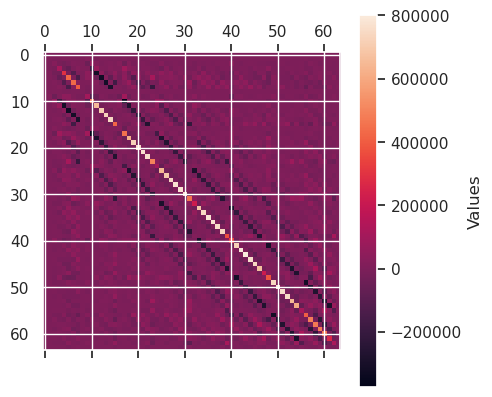

In [355]:
N_SAMPLES = 100
BETA_E = 1.0
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' # std / minmax
QUANT = False

d_dim, m_order = 2, 8
x, y, y_true = generate_x2_data(N_SAMPLES, d_dim, std_err=np.sqrt(1/BETA_E), seed=13)
x, _, y, _ = scale_data(x, jnp.empty_like(x), y, jnp.empty_like(y), TRANSFORM_X, TRANSFORM_Y, SCALER)
x, y = map(jnp.array, [x, y])
print(f'X stats (scaler: "{SCALER}"): Mean={x.mean(axis=0)}, Std={x.std(axis=0)}, Min={x.min()}, Max={x.max()}')

FMAP = PPNFeature()
gamma_w = 1e-6
fmap, dtype = prepare_fmap(FMAP, m_order, QUANT)
w_map = ls_sol(x, y, fmap, gamma_w, BETA_E)

grad_w = grad(l2_reg_loss_vanilla, argnums=0)
g_w = grad_w(w_map, x, y, fmap, gamma_w, BETA_E)

hess_f = hessian(l2_reg_loss_vanilla, argnums=0)
hw = hess_f(w_map, x, y, fmap, gamma_w, BETA_E)

F_mtx = get_design_mtx(x, fmap)
hw_hand = BETA_E*F_mtx.T.conj().dot(F_mtx) + gamma_w*jnp.eye(F_mtx.shape[1])

loss = l2_reg_loss_vanilla(w_map, x, y, fmap, gamma_w, BETA_E)
norm_grad = jnp.linalg.norm(g_w)
norm_diff_hess = jnp.linalg.norm(hw - hw_hand)
print(f"\nLoss: {loss:.4e}; Norm grad: {norm_grad}; Norm diff hess: {norm_diff_hess}")
print(f'\nW: Min={w_map.min():.1e}, Max={w_map.max():.1e}, Mean={w_map.mean():.1e}')

print('\nOrder 1. Cholesky -> Inverse -> Covariance matrix')
w_cholesky = np.linalg.cholesky(hw)
w_cholesky = np.linalg.pinv(w_cholesky.T)
w_cov = w_cholesky.dot(w_cholesky.T)
print('Is Covariance Matrix Symmetric?', (w_cov == w_cov.T).all())

plot_mtx(w_cov, '')

##### How to compute the covariance matrix?

In [217]:
N_SAMPLES = 100
BETA_E = 1.0
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' # std / minmax
QUANT = False

d_dim, m_order = 8, 2
x, y, y_true = generate_x2_data(N_SAMPLES, d_dim, std_err=np.sqrt(1/BETA_E), seed=13)
x, _, y, _ = scale_data(x, jnp.empty_like(x), y, jnp.empty_like(y), TRANSFORM_X, TRANSFORM_Y, SCALER)
x, y = map(jnp.array, [x, y])
print(f'X stats (scaler: "{SCALER}"): Mean={x.mean(axis=0)}, Std={x.std(axis=0)}, Min={x.min()}, Max={x.max()}')

FMAP = PPFeature()
gamma_w = 1e-6
fmap, dtype = prepare_fmap(FMAP, m_order, QUANT)
w_map = ls_sol(x, y, fmap, gamma_w, BETA_E)

grad_w = grad(l2_reg_loss_vanilla, argnums=0)
g_w = grad_w(w_map, x, y, fmap, gamma_w, BETA_E)

hess_f = hessian(l2_reg_loss_vanilla, argnums=0)
hw = hess_f(w_map, x, y, fmap, gamma_w, BETA_E)

F_mtx = get_design_mtx(x, fmap)
hw_hand = BETA_E*F_mtx.T.conj().dot(F_mtx) + gamma_w*jnp.eye(F_mtx.shape[1])

loss = l2_reg_loss_vanilla(w_map, x, y, fmap, gamma_w, BETA_E)
norm_grad = jnp.linalg.norm(g_w)
norm_diff_hess = jnp.linalg.norm(hw - hw_hand)
print(f"\nLoss: {loss:.4e}; Norm grad: {norm_grad}; Norm diff hess: {norm_diff_hess}")
print('Is Hessian Matrix Symmetric?', (hw_hand == hw_hand.T).all())

print('\nOrder 1. Cholesky -> Inverse -> Covariance matrix')
w_cholesky = np.linalg.cholesky(hw)
w_cholesky = np.linalg.pinv(w_cholesky.T)
w_cov = w_cholesky.dot(w_cholesky.T)
print('Is Covariance Matrix Symmetric?', (w_cov == w_cov.T).all())

print('\nOrder 2. Inverse -> Covariance matrix -> Cholesky')
w_cov = np.linalg.pinv(hw)
print('Is Covariance Matrix Symmetric?', (w_cov == w_cov.T).all())
#w_cholesky = np.linalg.cholesky(w_cov)
#plot_mtx(w_cov, '')
print(w_map.min(), w_map.max(), w_map.mean())

X stats (scaler: "std"): Mean=[-2.13162821e-16  1.42108547e-16 -1.06581410e-16 -3.55271368e-17
 -2.13162821e-16  2.13162821e-16  3.55271368e-17  1.77635684e-16], Std=[1. 1. 1. 1. 1. 1. 1. 1.], Min=-1.849712807858957, Max=1.8595832261635976

Loss: 1.4917e-03; Norm grad: 3.9756429853340226e-10; Norm diff hess: 0.0
Is Hessian Matrix Symmetric? True

Order 1. Cholesky -> Inverse -> Covariance matrix
Is Covariance Matrix Symmetric? True

Order 2. Inverse -> Covariance matrix -> Cholesky
Is Covariance Matrix Symmetric? False
-9.739898531950105 8.718603039558742 0.0006813273922480871


## CPD, ALS, Reg: $\|v\|_2^2$. Behavior during training? (07.03.2025)
- Gradients? 
- Loss?
- Linear system k-step?

In [2]:
LOSS_STR = 'Loss:\n' + r'$\mathcal{J}(\mathbf{v}) = 0.5*(\beta \|\mathbf{y} - \mathbf{\Phi} \mathbf{g}(\mathbf{v})\|^2_2 + \gamma \|\mathbf{v}\|_2^2)$'

def get_name(p_dict): 
    return (
        f"I{p_dict['m_order']}_R{p_dict['rank']}_G{p_dict['gamma_w']}_S{p_dict['seed']}"
        + f"_E{p_dict['n_epoch']}_B{p_dict['beta_e']}_F{p_dict['fmap']}"
    )

def get_text(
    n_samples=None, 
    d_dim=None, 
    m_order=None, 
    rank=None, 
    beta_e=None, 
    gamma_w=None, 
    n_epoch=None, 
    fmap=None,
    seed=None,
):
    text = LOSS_STR + '\n'
    if n_samples is not None:
        text += f'N={n_samples}; '
    if d_dim is not None:
        text += f'D={d_dim}; '
    if m_order is not None:
        text += f'I={m_order}; '
    if rank is not None:
        text += f'R={rank}; '
    text += '\n'
    if beta_e is not None:
        text += r'$\beta$=' + f'{beta_e:.2e}; '
    if gamma_w is not None:
        text += r'$\gamma$=' + f'{gamma_w:.2e}; '
    text += '\n'
    if n_epoch is not None:
        text += f'E={n_epoch}; '
    if fmap is not None:
        text += r'$\mathbf{\psi}(x)$-' + f'{fmap}; '
    text += '\n'
    return text

def plot_grad_norm(
    grad_norm_tracker, 
    save_path: Optional[str] = None,
    show_plot: bool = True,
    dpi: int = 200,
):
    d_dim = num_plots = len(grad_norm_tracker['j_core'].unique())
    cols = int(np.ceil(np.sqrt(num_plots))) 
    rows = int(np.ceil(num_plots / cols))
    with mpl.rc_context(PARAMS):
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
        axes = axes.flatten()  # Flatten in case of 2D array
        k = -1
        for j, ax in enumerate(axes):
            if j > d_dim - 1:
                continue
            j_df = query_df(grad_norm_tracker, dict(j_core=j))
            values = j_df['norm_grad'].values
            ax.plot(values, marker='*', linestyle='-', label=f'Last: {values[-1]:.2e}')
            k += 1
            
            steps = np.arange(len(values))
            every_ith = steps[::d_dim]
            ax.scatter(every_ith, values[::d_dim], color='black', marker='o', s=40, label="New Epoch")

            every_ith = steps[k::d_dim]
            ax.scatter(every_ith, values[k::d_dim], color='purple', marker='o', s=30, label="Core Update")

            if j >= (rows - 1) * cols: # Only add x-label to the last row of plots
                ax.set_xlabel('Step')
            else:
                ax.set_xlabel('')
            if j % cols == 0: # Only add y-label to the first column of plots
                ax.set_ylabel('Norm Gradient')
            else:
                ax.set_ylabel('')  
            ax.set_title(f'Core {j+1}')
            ax.grid(True)
            ax.legend()
        for i in range(num_plots, len(axes)):
            fig.delaxes(axes[i])
        plt.tight_layout()
        if save_path: 
            plt.savefig(save_path, dpi=dpi)
        if show_plot:
            plt.show()
        else:
            plt.close()

def plot_y_list( 
    y_list,
    x = None,
    leg_list=None,
    xlabel = 'Step',
    ylabel = 'Loss',
    title = '',
    x_scale='linear',
    y_scale='linear', # 'log'
    save_path: Optional[str] = None,
    show_plot: bool = True,
    dpi: int = 200,
    text: Optional[str] = None,  
):
    if x is None:
        x = np.arange(len(y_list[0]))
    with mpl.rc_context(PARAMS):
        plt.figure(figsize=(8, 4))
        for i, y in enumerate(y_list): 
            plt.plot(x, y, marker='*', linestyle='-', label='' if leg_list is None else leg_list[i]) 
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xscale(x_scale)
        plt.yscale(y_scale)
        plt.title(title)
        if leg_list:
            plt.legend()
        plt.tight_layout()
        if text:
            plt.text(
                1.05, 0.5, text, transform=plt.gca().transAxes, 
                fontsize=9, color='black', va='center'
            )
        if save_path: 
            plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        if show_plot:
            plt.show()
        else:
            plt.close()

def plot_dual_axis( 
    y1, 
    y2,
    x=None,
    leg_y1='',
    leg_y2='',
    xlabel='',
    y1_label='',
    y2_label='',
    x_scale='linear', # 'log'
    y1_scale='linear', # 'log'
    y2_scale='linear', # 'log'
    title='',
    save_path: Optional[str] = None,
    show_plot: bool = True,
    dpi: int = 200,
):
    if x is None:
        x = np.arange(len(y1))
    with mpl.rc_context(PARAMS):
        fig, ax1 = plt.subplots(figsize=(8, 4))
        # First Y-axis (Loss)
        ax1.plot(x, y1, marker='*', linestyle='-', color='b', label=leg_y1)
        ax1.set_xscale(x_scale)
        ax1.set_xlabel(xlabel)
        ax1.set_yscale(y1_scale)
        ax1.set_ylabel(y1_label, color='b')
        ax1.tick_params(axis='y', labelcolor='b')
        # Second Y-axis (Gradient Norm)
        ax2 = ax1.twinx()
        ax2.plot(x, y2, marker='o', linestyle='--', color='r', label=leg_y2)
        ax2.set_yscale(y2_scale)
        ax2.set_ylabel(y2_label, color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        # Add legends
        ax2.legend(loc="lower right", bbox_to_anchor=(1.0, 0.70))
        ax1.legend(loc="upper right", bbox_to_anchor=(1.0, 0.95))
        plt.xticks(x)
        plt.title(title)
        plt.grid(False)
        plt.tight_layout()
        if save_path: 
            plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        if show_plot:
            plt.show()
        else:
            plt.close()

### Adam:

In [3]:
def cpd_adam_estimate(w_ten, kd, x, y, fmap, n_epoch, gamma_w, beta_e, grad_w, lr, bs):
    m = jnp.zeros_like(ten3tovec(w_ten))
    v = jnp.zeros_like(m)
    t = 0  # Time step
    d_dim, I, R = w_ten.shape
    P = I*R
    grad_norm_tracker, loss_tracker = list(), list()
    for ep in range(n_epoch):
        w_vec = ten3tovec(w_ten)
        for x_batch, y_batch in get_batches(x, y, batch_size=bs):
            dw = grad_w(w_vec, kd, x_batch, y_batch, fmap, gamma_w, beta_e, w_ten.shape)
            w_vec, m, v, t = adam_update(w_vec, dw, m, v, t, lr)
        w_ten = vec2ten3(w_vec, *w_ten.shape)
        check_nan(w_ten)
        ### Save calculations:  
        # Track Loss:
        loss_val = l2_gb_loss(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
        loss_tracker.append((ep, loss_val))
        # Track Norm Grad:
        gd = grad_w(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)
        for jth in range(d_dim):
            grad_norm_tracker.append(
                (ep, jth, norm_frob(gd[jth*P:jth*P + P]).item())
            )
    return w_ten, grad_norm_tracker, loss_tracker

In [25]:
import optax

from source.model_functionality import predict_score
from source.matrix_operations import vec2ten3

def cpd_prediction(x, fmap, w_vec, kd, w_shape):
    w_ten = vec2ten3(w_vec, *w_shape)
    return predict_score(x, kd, w_ten, fmap)

def l2_gb_loss_optax(params, kd, w_shape, x, y, fmap, gamma_w, beta_e):
    w_vec = params['w_vec']
    scores = cpd_prediction(x, fmap, w_vec, kd, w_shape)
    data_fit = jnp.sum((y - scores)**2) # ??? jnp.sum or jnp.mean ???
    reg_fit = (w_vec * w_vec).sum()
    return 0.5*(beta_e*data_fit + gamma_w*reg_fit)

def fit(
    params: optax.Params, 
    kd, 
    w_shape, 
    x, 
    y, 
    fmap, 
    batch_size: int, 
    n_epoch, 
    gamma_w, 
    beta_e,
    optimizer: optax.GradientTransformation,
    grad_w,
) -> optax.Params:
    opt_state = optimizer.init(params)
    
    @jax.jit
    def step(params, opt_state, x_batch, y_batch):
        loss_value, grads = jax.value_and_grad(l2_gb_loss_optax)(params, kd, w_shape, x_batch, y_batch, fmap, gamma_w, beta_e)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_value
    
    d_dim, I, R = w_shape
    P = I*R
    grad_norm_tracker, loss_tracker = list(), list()
    for ep in range(n_epoch):
        for i, (x_batch, y_batch) in enumerate(get_batches(x, y, batch_size=batch_size)):
            params, opt_state, loss_value = step(params, opt_state, x_batch, y_batch)
        
        w_ten = vec2ten3(params['w_vec'], *w_shape)
        check_nan(w_ten)
        ### Save calculations:  
        # Track Loss:
        loss_val = l2_gb_loss_optax(params, kd, w_shape, x, y, fmap, gamma_w, beta_e).item()
        loss_tracker.append((ep, loss_val))
        # Track Norm Grad:
        gd = grad_w(params, kd, w_shape, x, y, fmap, gamma_w, beta_e)['w_vec']
        for jth in range(d_dim):
            grad_norm_tracker.append(
                (ep, jth, norm_frob(gd[jth*P:jth*P + P]).item())
            )
    return w_ten, grad_norm_tracker, loss_tracker

grad_w_optax = jit(grad(l2_gb_loss_optax, argnums=0), static_argnums=(2, 5))

def cpd_adam_estimate(w_ten, kd, x, y, fmap, n_epoch, gamma_w, beta_e, grad_w, lr, bs):
    params = {'w_vec': ten3tovec(w_ten)}
    optimizer = optax.adam(learning_rate=lr)
    w_ten, grad_norm_tracker, loss_tracker = fit(
        params, kd, w_ten.shape, x, y, fmap, bs, n_epoch, gamma_w, beta_e, optimizer, grad_w)
    return w_ten, grad_norm_tracker, loss_tracker

In [4]:
def train_cpd_adam(x, y, config, grad_w, res_dir, extra_name='', lr=5e-3, bs=64) -> None:
    # Prepare features and init weights:
    fmap, dtype = prepare_fmap(config['fmap'], config['m_order'], config['quant'])
    w_ten, kd = init_weights(
        config['m_order'], config['rank'], x.shape[1], q_base=config['q_base'], init_type=None, seed=config['seed'], dtype=dtype)
    # Training:
    w_ten, grad_norm_tracker, loss_tracker = cpd_adam_estimate(w_ten, kd, x, y, fmap, config['n_epoch'], config['gamma_w'], config['beta_e'], grad_w, lr, bs)
    # Post-Processing:
    id_str = (
        f"I{config['m_order']}_R{config['rank']}_G{config['gamma_w']}_S{config['seed']}"
        + f"_E{config['n_epoch']}_B{config['beta_e']}_F{config['fmap'].name}"
    ) # get_name(p_dict)
    loss_tracker = pd.DataFrame(loss_tracker, columns=['epoch', 'loss'])
    loss_tracker.to_csv(res_dir / f"loss_{id_str}{extra_name}.csv")
    
    grad_norm_tracker = pd.DataFrame(grad_norm_tracker, columns=['epoch', 'j_core', 'norm_grad'])
    grad_norm_tracker.to_csv(res_dir / f"grad_norm_{id_str}{extra_name}.csv")

    stats_tracker = {'final_rank': [(~check_zero_cols(w_ten).all(axis=0)).sum()]}
    stats_tracker = pd.DataFrame(stats_tracker)
    stats_tracker.to_csv(res_dir / f"stats_{id_str}{extra_name}.csv")

#### Dependence on Initialization:

In [8]:
DATA_NAME = 'energy'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'adam'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[i for i in range(100)], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        train_cpd_adam(x, y, config | fixed_config, grad_w, RES_DIR, lr=5e-2, bs=128)

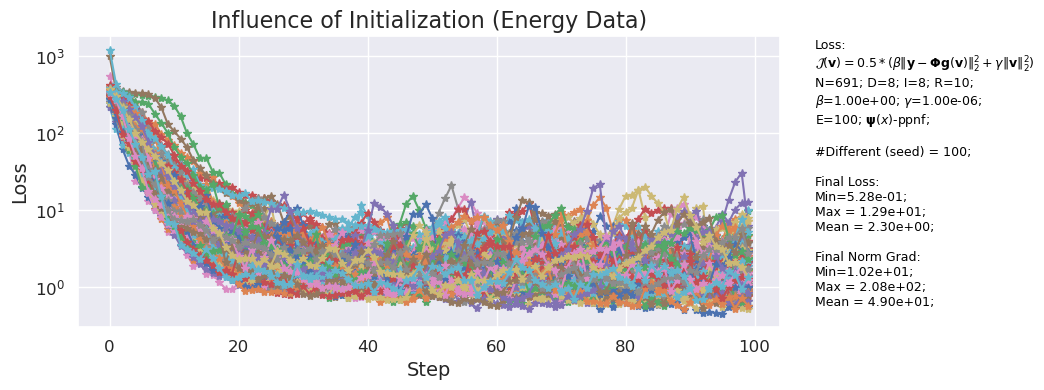

In [9]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 0
check_param = 'seed'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val})
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}.csv")

    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Initialization ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_init.png'
plot_y_list(loss_tracker_list, y_scale='log', title=title, save_path=save_path, text=text)

#### Dependence on Ranks:

In [16]:
DATA_NAME = 'energy'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'adam'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[2, 4, 8, 16, 24, 32, 50, 64, 75, 90, 120, 150],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        train_cpd_adam(x, y, config | fixed_config, grad_w, RES_DIR, lr=5e-2, bs=128)

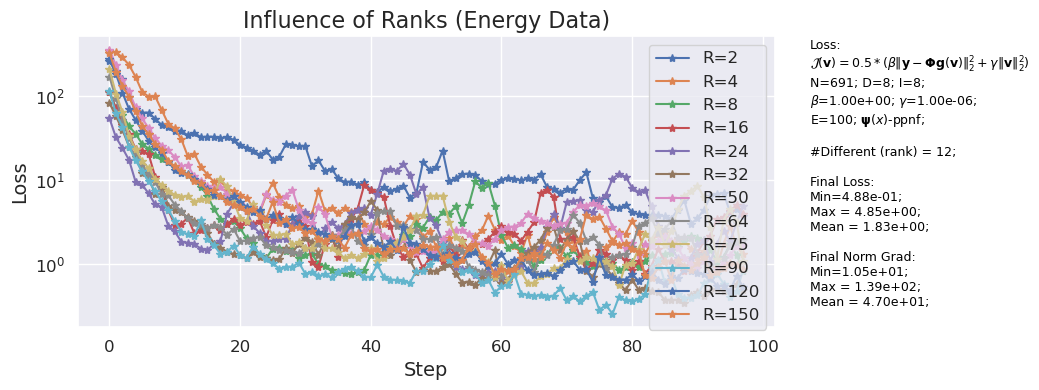

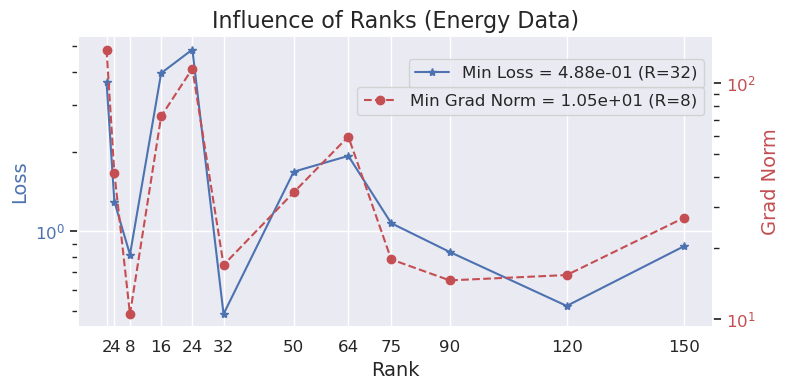

In [17]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'rank'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val})
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}.csv")

    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Ranks ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_ranks.png'
leg_list = [f"R={i}" for i in params[check_param]]
plot_y_list(loss_tracker_list, y_scale='log', leg_list=leg_list, title=title, save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_ranks.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=params[check_param],
    leg_y1=f'Min Loss = {min(last_loss):.2e} (R={params[check_param][np.argmin(last_loss)]})',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e} (R={params[check_param][np.argmin(grad_norm_last_list)]})',
    xlabel=check_param.capitalize(),
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

#### Dependence on Local Mapping Dimension:

In [ ]:
DATA_NAME = 'energy'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'adam'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[2, 4, 8, 16, 32, 64, 90, 128, 256],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        train_cpd_adam(x, y, config | fixed_config, grad_w, RES_DIR, lr=5e-2, bs=128)

100%|██████████| 9/9 [00:51<00:00,  5.67s/it]


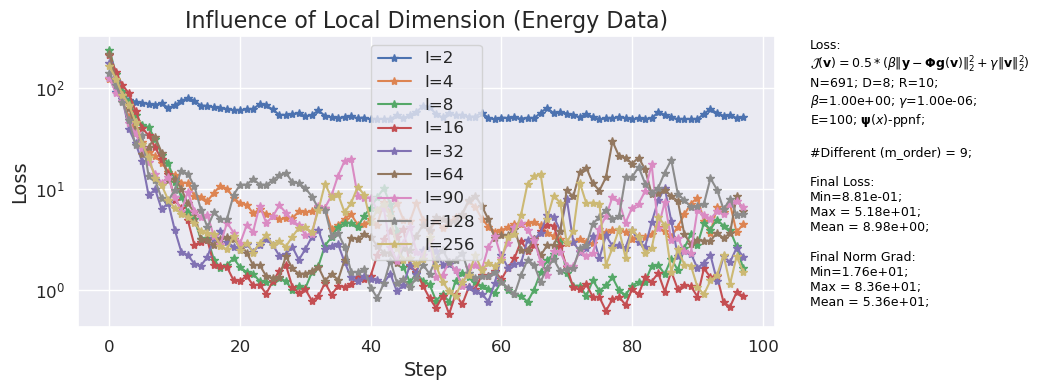

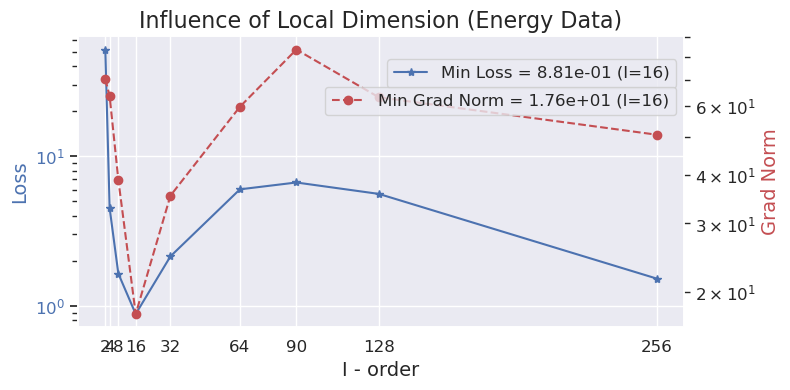

In [21]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'm_order'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val})
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}.csv")
    stats_tracker = pd.read_csv(RES_DIR / f"stats_{id_str}.csv")

    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Local Dimension ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_m_order.png'
leg_list = [f"I={i}" for i in params[check_param]]
plot_y_list(loss_tracker_list, leg_list=leg_list, title=title, y_scale='log', save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_m_order.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=params[check_param],
    leg_y1=f'Min Loss = {min(last_loss):.2e} (I={params[check_param][np.argmin(last_loss)]})',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e} (I={params[check_param][np.argmin(grad_norm_last_list)]})',
    xlabel='I - order',
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

#### Dependence on Gamma_w:

In [ ]:
DATA_NAME = 'energy'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'adam'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        train_cpd_adam(x, y, config | fixed_config, grad_w, RES_DIR, lr=5e-2, bs=128)

100%|██████████| 9/9 [00:16<00:00,  1.81s/it]


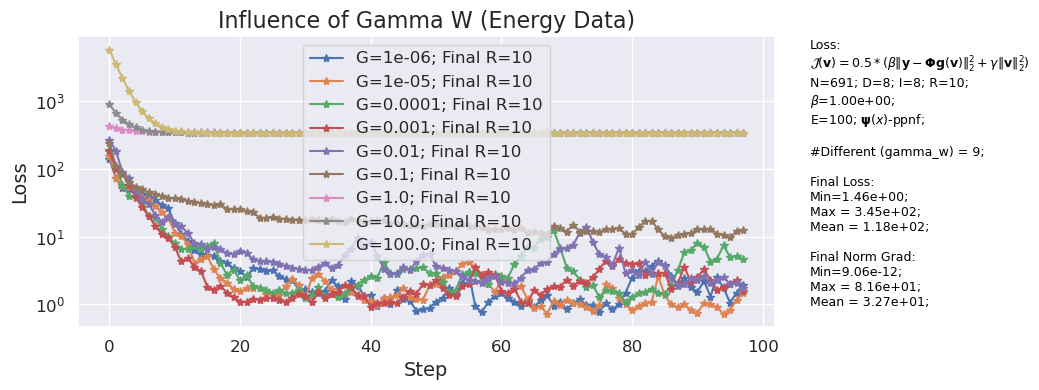

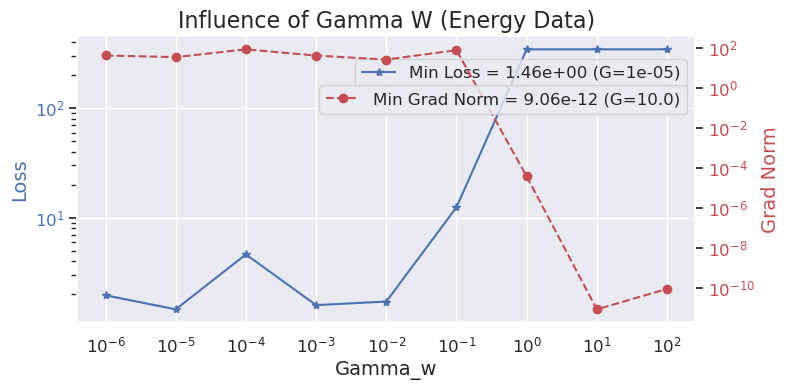

In [25]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'gamma_w'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
final_rank_list = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val})
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}.csv")
    stats_tracker = pd.read_csv(RES_DIR / f"stats_{id_str}.csv")
    
    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)
    final_rank_list.append(stats_tracker['final_rank'].values[0])
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Gamma W ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_gamma.png'
leg_list = [f"G={i}; Final R={j}" for i, j in zip(params[check_param], final_rank_list)]
plot_y_list(loss_tracker_list, leg_list=leg_list, title=title, y_scale='log', save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_gamma.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=params[check_param],
    leg_y1=f'Min Loss = {min(last_loss):.2e} (G={params[check_param][np.argmin(last_loss)]})',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e} (G={params[check_param][np.argmin(grad_norm_last_list)]})',
    xlabel=check_param.capitalize(),
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='log',
    y1_scale='log',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

#### Dependence on #Epochs:

In [30]:
DATA_NAME = 'energy'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = True

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'adam'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[10000,],
    seed=[13,], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        train_cpd_adam(x, y, config | fixed_config, grad_w, RES_DIR, lr=5e-2, bs=128)

100%|██████████| 1/1 [02:11<00:00, 131.32s/it]


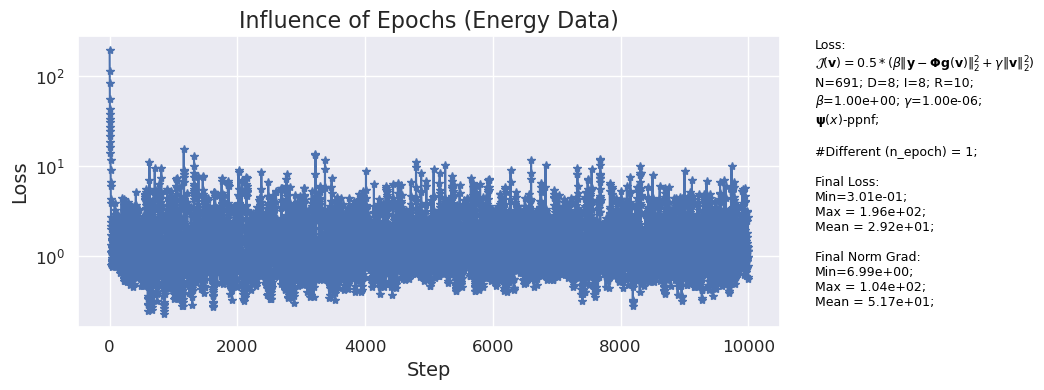

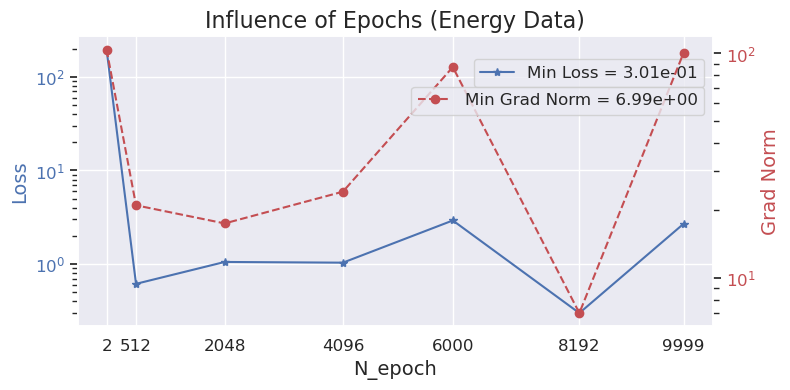

In [31]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'n_epoch'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
last_loss = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val})
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}.csv")
    stats_tracker = pd.read_csv(RES_DIR / f"stats_{id_str}.csv")

    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)

    epoch_list = [2, 512, 2048, 4096, 6000, 8192] + [loss_tracker['epoch'].max()]
    for ep in epoch_list:
        ep_loss = query_df(loss_tracker, dict(epoch=ep))
        ep_gn = query_df(grad_norm_tracker, dict(epoch=ep))
        gn_last = ep_gn['norm_grad'].values
        grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
        last_loss.append(ep_loss['loss'].values[-1])

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Epochs ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_n_epochs.png'
leg_list = [f"G={i}; Final R={j}" for i, j in zip(params[check_param], final_rank_list)]
plot_y_list(loss_tracker_list, leg_list=None, title=title, y_scale='log', save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_n_epochs.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=epoch_list,
    leg_y1=f'Min Loss = {min(last_loss):.2e}',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e}',
    xlabel=check_param.capitalize(),
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

#### Dependence on Data Dimensionality - D. Synthetic Data.

In [32]:
from source.data_functions import scale_data

def generate_random_x(n_samples, d_dim, min_v=-4, max_v=4, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    x = rs.uniform(min_v, max_v, (n_samples, d_dim))
    if sort_x:
        x = np.sort(x, axis=0)
    return x
    
def generate_x2_data(n_samples, d_dim, min_v=-4, max_v=4, std_err=3, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    x = generate_random_x(n_samples, d_dim, min_v, max_v, seed, sort_x)
    e = rs.normal(0.0, std_err, (n_samples,))
    y_true = (x**2).sum(axis=1)
    y = y_true + e
    return x, y, y_true

def generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, std_err=1.0, min_v=-4, max_v=4, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    n_samples_test = int(n_samples / 4)
    x = generate_random_x(n_samples, d_dim, min_v, max_v, seed, sort_x)
    x_test = generate_random_x(n_samples_test, d_dim, min_v, max_v, seed, sort_x)

    x, x_test, _, _ = scale_data(x, x_test, [1], [1], True, False, 'std')
    x, x_test = map(jnp.array, [x, x_test])

    fmap, dtype = prepare_fmap(fmap_tuple, m_order, False)
    w_ten, kd = init_weights(m_order, rank, d_dim, q_base=None, init_type=None, seed=seed, dtype=dtype)
    y_true, y_test_true = predict_score(x, kd, w_ten, fmap), predict_score(x_test, kd, w_ten, fmap)
    y = y_true + rs.normal(0.0, std_err, (n_samples,))
    y_test = y_test_true + rs.normal(0.0, std_err, (n_samples_test,))
    return x, x_test, y, y_test

In [40]:
DATA_NAME = 'Model_Data'
TRAIN = False

N_SAMPLES = 100
TRAIN_METHOD = 'adam'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,], 
)
params = {k:v[0] for k, v in params.items()}

d_dim_list = [2, 4, 8, 16, 32, 64, 128]

fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for d_dim in tqdm(d_dim_list):
        x, x_test, y, y_test = generate_model_data(
            N_SAMPLES, d_dim, 
            m_order=params['m_order'],
            rank=params['rank'],
            fmap_tuple=params['fmap'],
            std_err=params['beta_e'],
            seed=1,
        )
        extra_name = f'_D{d_dim}'
        train_cpd_adam(x, y, params | fixed_config, grad_w, RES_DIR, extra_name, lr=5e-2, bs=128)

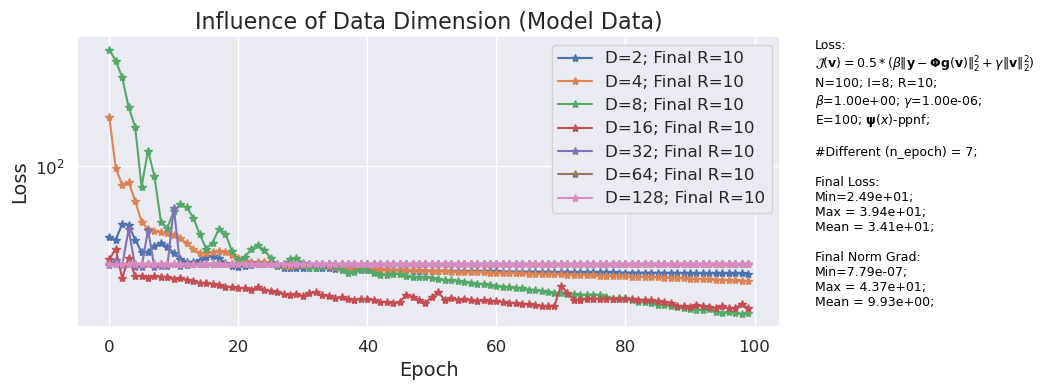

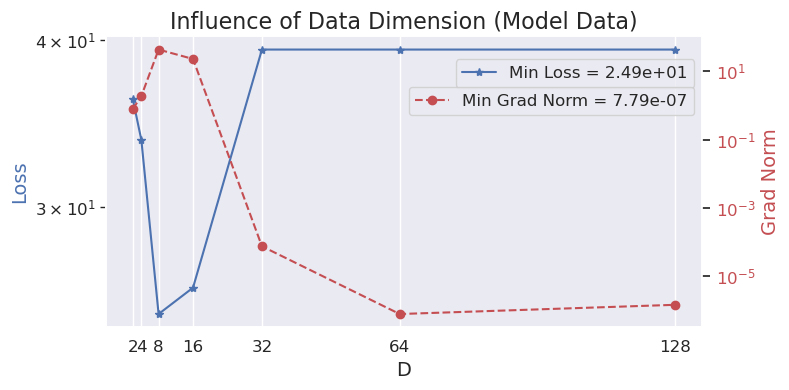

In [42]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2

p_fixed = {k:v for k, v in params.items()}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
final_rank_list = []
for d_dim in d_dim_list:
    extra_name = f'_D{d_dim}'
    id_str = get_name(p_fixed)
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}{extra_name}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}{extra_name}.csv")
    stats_tracker = pd.read_csv(RES_DIR / f"stats_{id_str}{extra_name}.csv")

    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker.groupby('epoch')['loss'].mean().values)
    final_rank_list.append(stats_tracker['final_rank'].values[0])
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(N_SAMPLES, d_dim=None, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

leg_list = [f"D={i}; Final R={j}" for i, j in zip(d_dim_list, final_rank_list)]
title = f'Influence of Data Dimension (Model Data)'
save_path = SAVE_DIR / 'loss_D.png'
plot_y_list(loss_tracker_list, x=None, xlabel='Epoch', leg_list=leg_list, title=title, y_scale='log', save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_D.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=d_dim_list,
    leg_y1=f'Min Loss = {min(last_loss):.2e}',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e}',
    xlabel='D',
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

#### Dependence on Feature Maps:

In [59]:
DATA_NAME = 'yacht'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'adam'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10, ],
    fmap=[
        RBFFeature(l_scale=0.001), 
        RBFFeature(l_scale=0.01),
        RBFFeature(l_scale=0.1),
        RBFFeature(l_scale=1),
        RBFFeature(l_scale=2),
        PPNFeature(), 
        PPFeature()
    ],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        if config['fmap'].name == 'rbff':
            extra_name = f'_ls{config['fmap'].l_scale}'
        else:
            extra_name = ''
        train_cpd_adam(x, y, config | fixed_config, grad_w, RES_DIR, extra_name, lr=5e-2, bs=128)

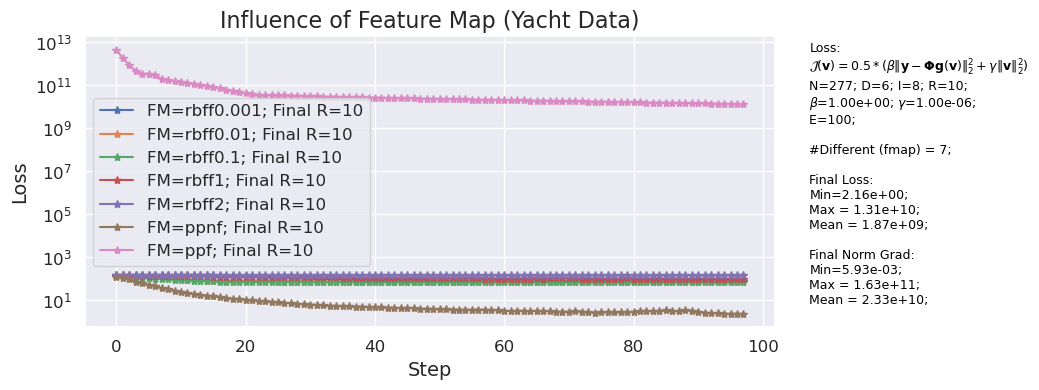

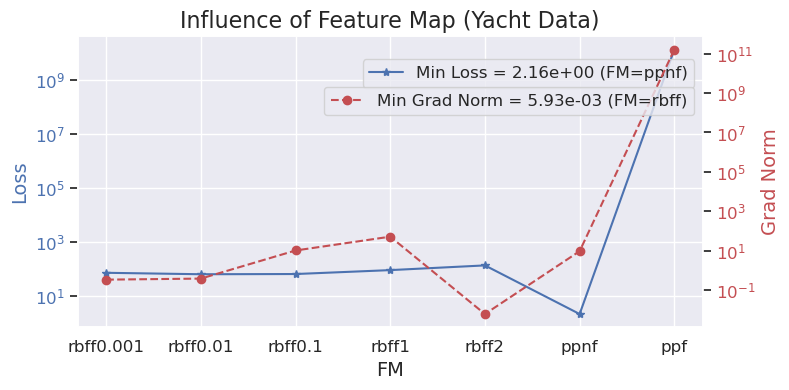

In [60]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'fmap'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
loss_tracker_list = []
grad_norm_last_list = []
final_rank_list = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val.name})
    if p_val.name == 'rbff':
        extra_name = f'_ls{p_val.l_scale}'
    else:
        extra_name = ''
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}{extra_name}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}{extra_name}.csv")
    stats_tracker = pd.read_csv(RES_DIR / f"stats_{id_str}{extra_name}.csv")
    
    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)
    final_rank_list.append(stats_tracker['final_rank'].values[0])
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Feature Map ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_fmap.png'
leg_list = [f"FM={i.name}{i.l_scale if i.name == 'rbff' else ''}; Final R={j}" for i, j in zip(params[check_param], final_rank_list)]
plot_y_list(loss_tracker_list, leg_list=leg_list, title=title, y_scale='log', save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_fmap.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=[f"{i.name}{i.l_scale if i.name == 'rbff' else ''}" for i in params[check_param]],
    leg_y1=f'Min Loss = {min(last_loss):.2e} (FM={params[check_param][np.argmin(last_loss)].name})',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e} (FM={params[check_param][np.argmin(grad_norm_last_list)].name})',
    xlabel='FM',
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

### ALS:

In [46]:
def cpd_als_estimate(w_ten, kd, x, y, fmap, n_epoch, gamma_w, beta_e, grad_w):
    grad_norm_tracker, loss_tracker = list(), list()
    fw_hadamard, ww_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap), get_ww_hadamard_mtx(w_ten)
    d_dim, I, R = w_ten.shape
    P = I*R
    for ep in range(n_epoch):
        for ind in range(w_ten.shape[0]):
            # Preprocess:
            k, q = divmod(ind, kd) # q starts from zero -> for fmap
            wk, fk_mtx = w_ten[ind], fmap(x[:, k], q)
            fw_hadamard /= (fk_mtx.dot(wk) + 1e-14) # ZERO DIVISION?
            ww_hadamard /= (wk.T.conj().dot(wk) + 1e-14) # ZERO DIVISION?
            # Solve linear system:
            alpha = gamma_w / beta_e
            (_, f_dim), (rank, _) = fk_mtx.shape, ww_hadamard.shape
            A, b = prepare_system(fk_mtx, fw_hadamard, y)
            A += alpha * jnp.eye(f_dim*rank)
            sol = np.linalg.solve(A, b)
            wk = jnp.array(sol.reshape(f_dim, rank, order='F')) # Fortran Ordering
            w_ten = w_ten.at[ind].set(wk)
            # Postprocess:
            fw_hadamard *= fk_mtx.dot(wk)
            ww_hadamard *= wk.T.conj().dot(wk)
            check_nan(w_ten)
        
            ### Save calculations:  
            # Track Loss:
            loss_val = l2_gb_loss(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
            loss_tracker.append((ep, ind, loss_val))
            # Track Norm Grad:
            gd = grad_w(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)
            for jth in range(d_dim):
                grad_norm_tracker.append(
                    (ep, ind, jth, norm_frob(gd[jth*P:jth*P + P]).item())
                )
    return w_ten, grad_norm_tracker, loss_tracker

def train_cpd_als(x, y, config, grad_w, res_dir, extra_name='') -> None:
    # Prepare features and init weights:
    fmap, dtype = prepare_fmap(config['fmap'], config['m_order'], config['quant'])
    w_ten, kd = init_weights(
        config['m_order'], config['rank'], x.shape[1], q_base=config['q_base'], init_type=None, seed=config['seed'], dtype=dtype)
    # Training:
    w_ten, grad_norm_tracker, loss_tracker = cpd_als_estimate(w_ten, kd, x, y, fmap, config['n_epoch'], config['gamma_w'], config['beta_e'], grad_w)
    # Post-Processing:
    id_str = (
        f"I{config['m_order']}_R{config['rank']}_G{config['gamma_w']}_S{config['seed']}"
        + f"_E{config['n_epoch']}_B{config['beta_e']}_F{config['fmap'].name}"
    ) # get_name(p_dict)
    loss_tracker = pd.DataFrame(loss_tracker, columns=['epoch', 'k_core_upd', 'loss'])
    loss_tracker.to_csv(res_dir / f"loss_{id_str}{extra_name}.csv")
    
    grad_norm_tracker = pd.DataFrame(grad_norm_tracker, columns=['epoch', 'k_core_upd', 'j_core', 'norm_grad'])
    grad_norm_tracker.to_csv(res_dir / f"grad_norm_{id_str}{extra_name}.csv")

    stats_tracker = {'final_rank': [(~check_zero_cols(w_ten).all(axis=0)).sum()]}
    stats_tracker = pd.DataFrame(stats_tracker)
    stats_tracker.to_csv(res_dir / f"stats_{id_str}{extra_name}.csv")

#### Dependence on Initialization:

In [ ]:
DATA_NAME = 'yacht'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'als'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[i for i in range(200)], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        train_cpd_als(x, y, config | fixed_config, grad_w, RES_DIR)

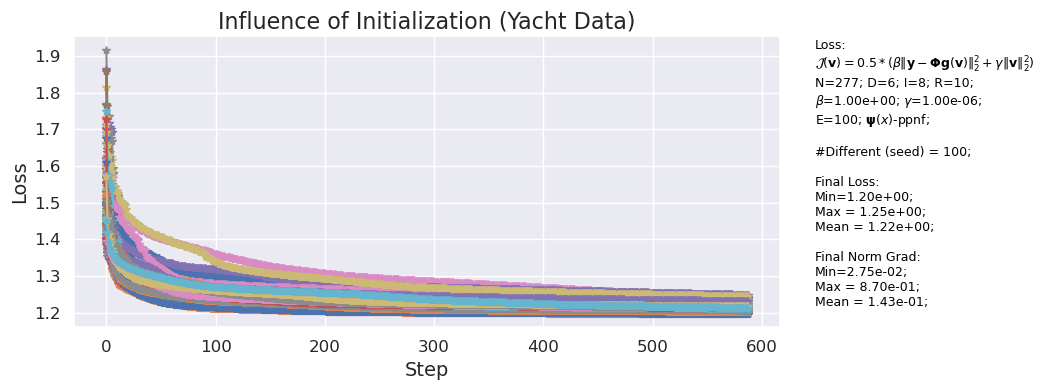

In [15]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'seed'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val})
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}.csv")

    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max(), k_core_upd=grad_norm_tracker['k_core_upd'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Initialization ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_init.png'
plot_y_list(loss_tracker_list, title=title, save_path=save_path, text=text)

#### Dependence on Ranks:

In [34]:
DATA_NAME = 'energy'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'als'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[2, 4, 8, 16, 24, 32, 50, 64, 75, 90, 120, 150],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        train_cpd_als(x, y, config | fixed_config, grad_w, RES_DIR)

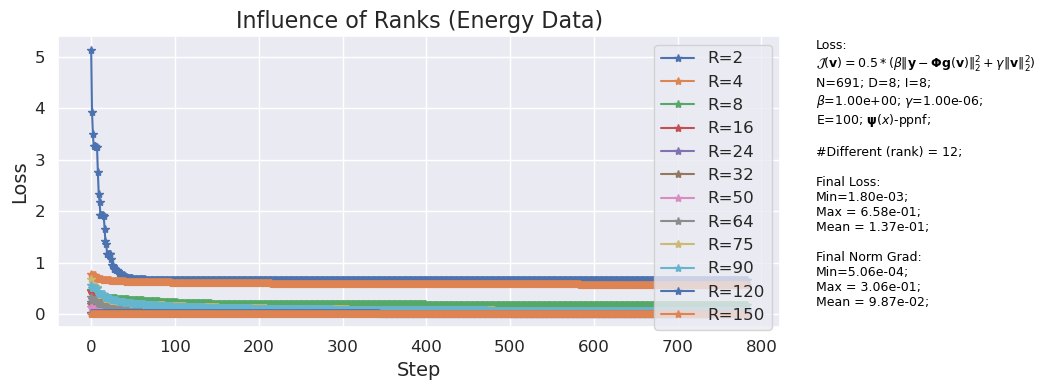

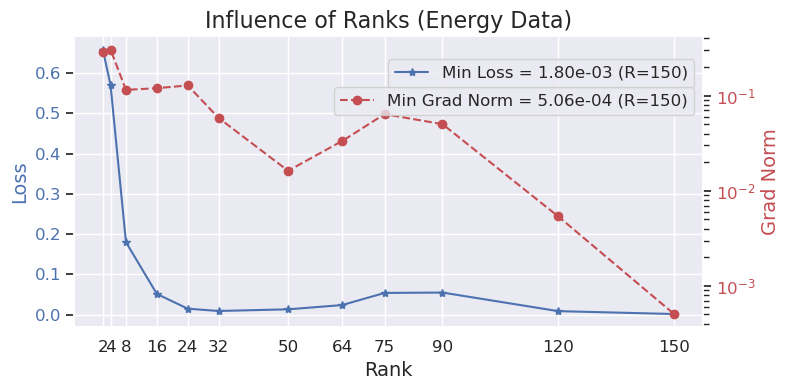

In [35]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'rank'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val})
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}.csv")

    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max(), k_core_upd=grad_norm_tracker['k_core_upd'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Ranks ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_ranks.png'
leg_list = [f"R={i}" for i in params[check_param]]
plot_y_list(loss_tracker_list, y_scale='linear', leg_list=leg_list, title=title, save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_ranks.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=params[check_param],
    leg_y1=f'Min Loss = {min(last_loss):.2e} (R={params[check_param][np.argmin(last_loss)]})',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e} (R={params[check_param][np.argmin(grad_norm_last_list)]})',
    xlabel=check_param.capitalize(),
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='linear',
    y1_scale='linear',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

#### Dependence on Local Mapping Dimension:

In [39]:
DATA_NAME = 'yacht'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'als'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[2, 4, 8, 16, 32, 64, 90, 128, 256],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        train_cpd_als(x, y, config | fixed_config, grad_w, RES_DIR)

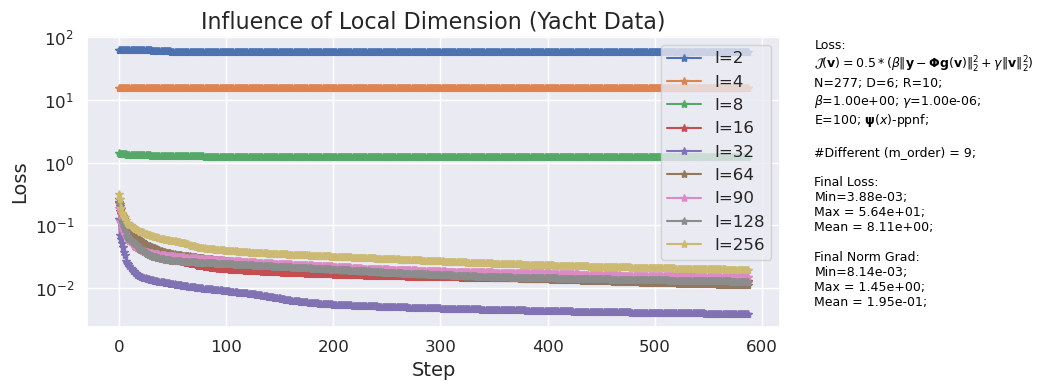

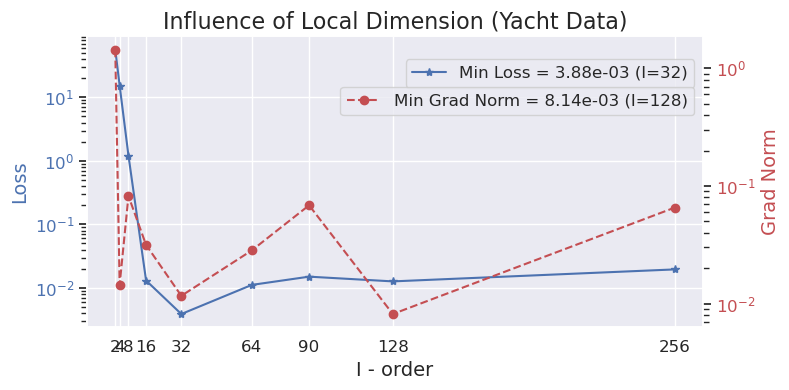

In [40]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'm_order'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val})
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}.csv")
    stats_tracker = pd.read_csv(RES_DIR / f"stats_{id_str}.csv")

    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max(), k_core_upd=grad_norm_tracker['k_core_upd'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Local Dimension ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_m_order.png'
leg_list = [f"I={i}" for i in params[check_param]]
plot_y_list(loss_tracker_list, leg_list=leg_list, title=title, y_scale='log', save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_m_order.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=params[check_param],
    leg_y1=f'Min Loss = {min(last_loss):.2e} (I={params[check_param][np.argmin(last_loss)]})',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e} (I={params[check_param][np.argmin(grad_norm_last_list)]})',
    xlabel='I - order',
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

#### Dependence on Gamma_w:

In [43]:
DATA_NAME = 'yacht'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'als'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        train_cpd_als(x, y, config | fixed_config, grad_w, RES_DIR)

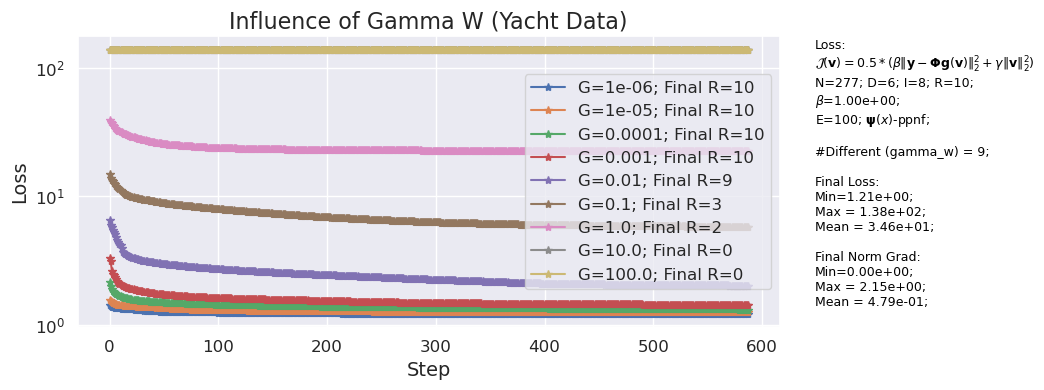

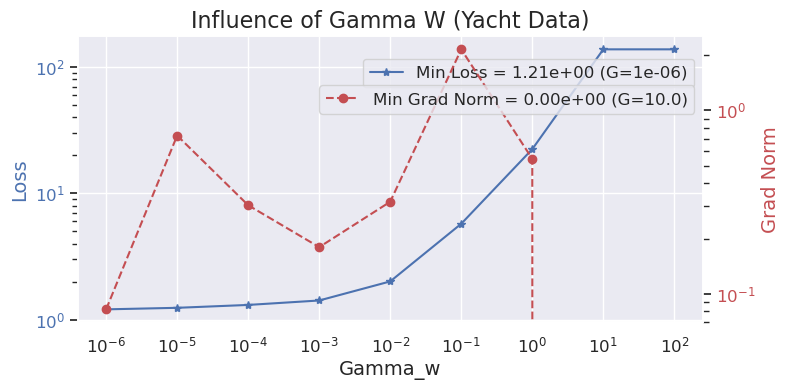

In [44]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'gamma_w'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
final_rank_list = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val})
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}.csv")
    stats_tracker = pd.read_csv(RES_DIR / f"stats_{id_str}.csv")
    
    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max(), k_core_upd=grad_norm_tracker['k_core_upd'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)
    final_rank_list.append(stats_tracker['final_rank'].values[0])
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Gamma W ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_gamma.png'
leg_list = [f"G={i}; Final R={j}" for i, j in zip(params[check_param], final_rank_list)]
plot_y_list(loss_tracker_list, leg_list=leg_list, title=title, y_scale='log', save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_gamma.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=params[check_param],
    leg_y1=f'Min Loss = {min(last_loss):.2e} (G={params[check_param][np.argmin(last_loss)]})',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e} (G={params[check_param][np.argmin(grad_norm_last_list)]})',
    xlabel=check_param.capitalize(),
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='log',
    y1_scale='log',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

#### Dependence on #Epochs:

In [47]:
DATA_NAME = 'yacht'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'als'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[10000,],
    seed=[13,], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        train_cpd_als(x, y, config | fixed_config, grad_w, RES_DIR)

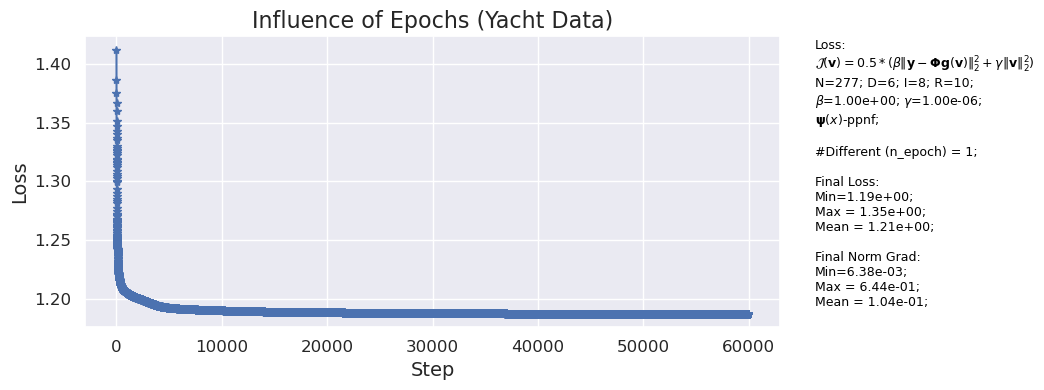

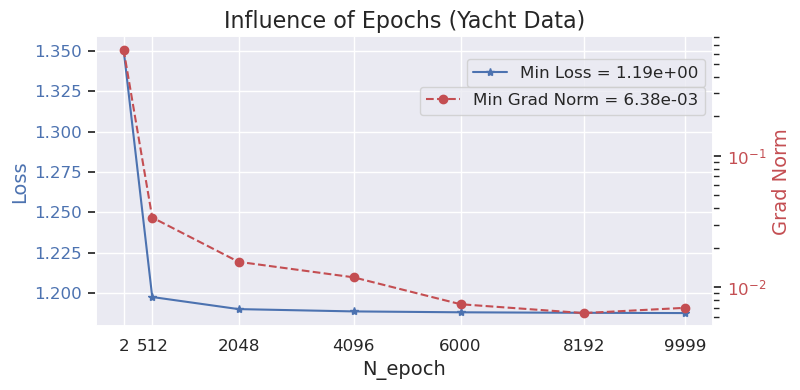

In [48]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'n_epoch'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
last_loss = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val})
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}.csv")
    stats_tracker = pd.read_csv(RES_DIR / f"stats_{id_str}.csv")

    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)

    epoch_list = [2, 512, 2048, 4096, 6000, 8192] + [loss_tracker['epoch'].max()]
    for ep in epoch_list:
        ep_loss = query_df(loss_tracker, dict(epoch=ep))
        ep_gn = query_df(grad_norm_tracker, dict(epoch=ep))
        gn_last = query_df(
            ep_gn, 
            dict(k_core_upd=ep_gn['k_core_upd'].max())
        )['norm_grad'].values
        grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
        last_loss.append(ep_loss['loss'].values[-1])

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Epochs ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_n_epochs.png'
leg_list = [f"G={i}; Final R={j}" for i, j in zip(params[check_param], final_rank_list)]
plot_y_list(loss_tracker_list, leg_list=None, title=title, y_scale='linear', save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_n_epochs.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=epoch_list,
    leg_y1=f'Min Loss = {min(last_loss):.2e}',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e}',
    xlabel=check_param.capitalize(),
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='linear',
    y1_scale='linear',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

#### Dependence on Data Dimensionality - D. Synthetic Data.

In [3]:
from source.data_functions import scale_data

def generate_random_x(n_samples, d_dim, min_v=-4, max_v=4, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    x = rs.uniform(min_v, max_v, (n_samples, d_dim))
    if sort_x:
        x = np.sort(x, axis=0)
    return x
    
def generate_x2_data(n_samples, d_dim, min_v=-4, max_v=4, std_err=3, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    x = generate_random_x(n_samples, d_dim, min_v, max_v, seed, sort_x)
    e = rs.normal(0.0, std_err, (n_samples,))
    y_true = (x**2).sum(axis=1)
    y = y_true + e
    return x, y, y_true

def generate_model_data(n_samples, d_dim, m_order, rank, fmap_tuple, std_err=1.0, min_v=-4, max_v=4, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    n_samples_test = int(n_samples / 4)
    x = generate_random_x(n_samples, d_dim, min_v, max_v, seed, sort_x)
    x_test = generate_random_x(n_samples_test, d_dim, min_v, max_v, seed, sort_x)

    x, x_test, _, _ = scale_data(x, x_test, [1], [1], True, False, 'std')
    x, x_test = map(jnp.array, [x, x_test])

    fmap, dtype = prepare_fmap(fmap_tuple, m_order, False)
    w_ten, kd = init_weights(m_order, rank, d_dim, q_base=None, init_type=None, seed=seed, dtype=dtype)
    y_true, y_test_true = predict_score(x, kd, w_ten, fmap), predict_score(x_test, kd, w_ten, fmap)
    y = y_true + rs.normal(0.0, std_err, (n_samples,))
    y_test = y_test_true + rs.normal(0.0, std_err, (n_samples_test,))
    return x, x_test, y, y_test

In [49]:
DATA_NAME = 'Model_Data'
TRAIN = False

N_SAMPLES = 100
TRAIN_METHOD = 'als'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,], 
)
params = {k:v[0] for k, v in params.items()}

d_dim_list = [2, 4, 8, 16, 32, 64, 128]

fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for d_dim in tqdm(d_dim_list):
        x, x_test, y, y_test = generate_model_data(
            N_SAMPLES, d_dim, 
            m_order=params['m_order'],
            rank=params['rank'],
            fmap_tuple=params['fmap'],
            std_err=params['beta_e'],
            seed=1,
        )
        extra_name = f'_D{d_dim}'
        train_cpd_als(x, y, params | fixed_config, grad_w, RES_DIR, extra_name)

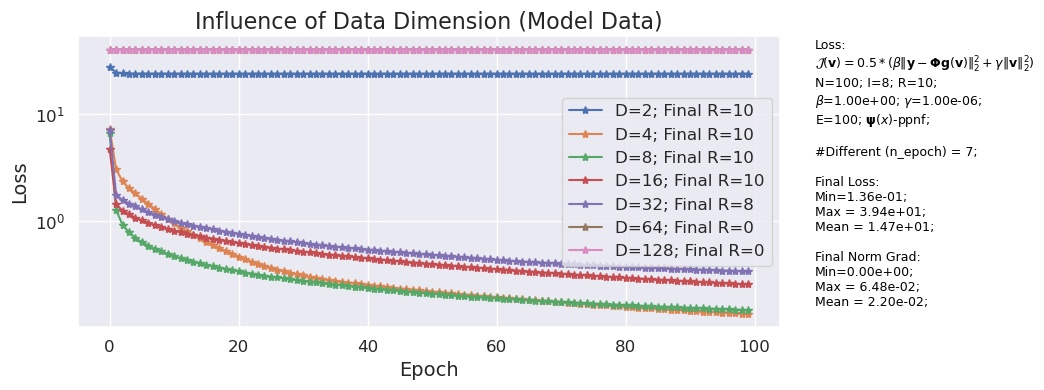

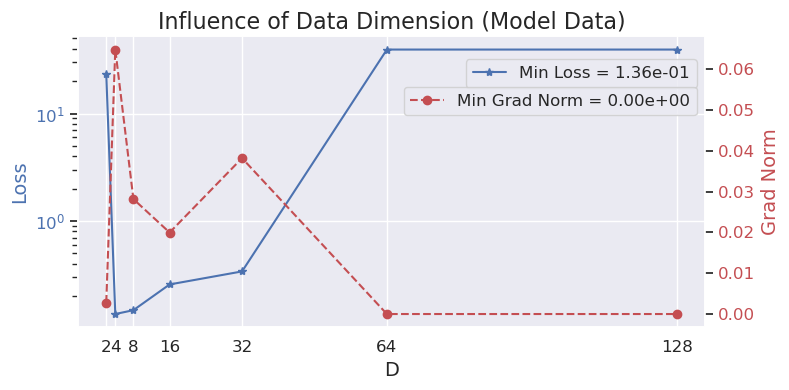

In [50]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2

p_fixed = {k:v for k, v in params.items()}
p_fixed['fmap'] = p_fixed['fmap'].name
loss_tracker_list = []
grad_norm_last_list = []
final_rank_list = []
for d_dim in d_dim_list:
    extra_name = f'_D{d_dim}'
    id_str = get_name(p_fixed)
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}{extra_name}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}{extra_name}.csv")
    stats_tracker = pd.read_csv(RES_DIR / f"stats_{id_str}{extra_name}.csv")

    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max(), k_core_upd=grad_norm_tracker['k_core_upd'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker.groupby('epoch')['loss'].mean().values)
    final_rank_list.append(stats_tracker['final_rank'].values[0])
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(N_SAMPLES, d_dim=None, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

leg_list = [f"D={i}; Final R={j}" for i, j in zip(d_dim_list, final_rank_list)]
title = f'Influence of Data Dimension (Model Data)'
save_path = SAVE_DIR / 'loss_D.png'
plot_y_list(loss_tracker_list, x=None, xlabel='Epoch', leg_list=leg_list, title=title, y_scale='log', save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_D.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=d_dim_list,
    leg_y1=f'Min Loss = {min(last_loss):.2e}',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e}',
    xlabel='D',
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='linear',
    y1_scale='log',
    y2_scale='linear',
    title=title, 
    save_path=save_path,
)

In [54]:
#plot_grad_norm(grad_norm_tracker[grad_norm_tracker['epoch'] < 2])

#### Dependence on Feature Maps:

In [47]:
DATA_NAME = 'energy'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
n_samples, d_dim = x.shape

TRAIN_METHOD = 'als'
RES_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10, ],
    fmap=[
        RBFFeature(l_scale=0.001), 
        RBFFeature(l_scale=0.01),
        RBFFeature(l_scale=0.1),
        RBFFeature(l_scale=1),
        RBFFeature(l_scale=2),
        PPNFeature(), 
        PPFeature()
    ],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,], 
)
grid, param_names = full_grid(params)
fixed_config = dict(quant=False, q_base=None)
grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
if TRAIN:
    for v in tqdm(grid):
        config = dict(zip(param_names, v))
        if config['fmap'].name == 'rbff':
            extra_name = f'_ls{config['fmap'].l_scale}'
        else:
            extra_name = ''
        train_cpd_als(x, y, config | fixed_config, grad_w, RES_DIR, extra_name)

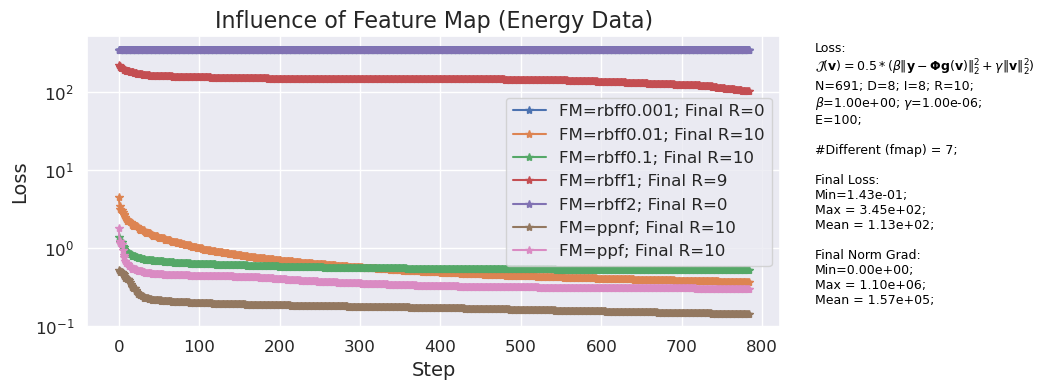

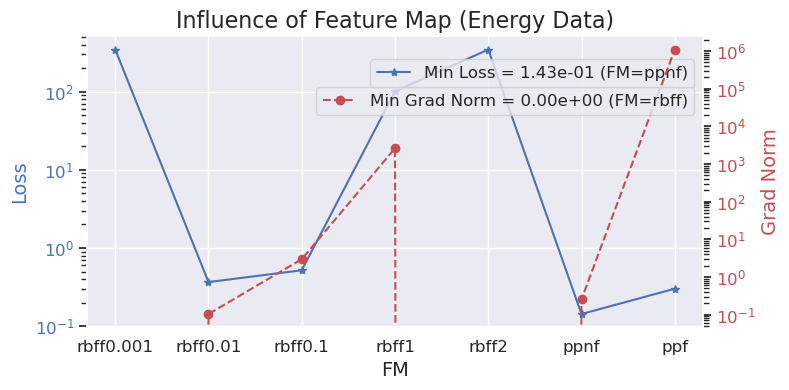

In [48]:
SAVE_DIR = Path(f'./artifacts/map_search/{TRAIN_METHOD}/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

start_with_ep = 2
check_param = 'fmap'

p_fixed = {k:v[0] for k, v in params.items() if k != check_param}
loss_tracker_list = []
grad_norm_last_list = []
final_rank_list = []
for p_val in params[check_param]:
    id_str = get_name(p_fixed | {check_param: p_val.name})
    if p_val.name == 'rbff':
        extra_name = f'_ls{p_val.l_scale}'
    else:
        extra_name = ''
    grad_norm_tracker = pd.read_csv(RES_DIR / f"grad_norm_{id_str}{extra_name}.csv")
    loss_tracker = pd.read_csv(RES_DIR / f"loss_{id_str}{extra_name}.csv")
    stats_tracker = pd.read_csv(RES_DIR / f"stats_{id_str}{extra_name}.csv")
    
    gn_last = query_df(
        grad_norm_tracker, 
        dict(epoch=grad_norm_tracker['epoch'].max(), k_core_upd=grad_norm_tracker['k_core_upd'].max())
    )['norm_grad'].values
    grad_norm_last_list.append(np.sqrt((gn_last**2).sum()))
    loss_tracker_list.append(loss_tracker[loss_tracker['epoch'] >= start_with_ep]['loss'].values)
    final_rank_list.append(stats_tracker['final_rank'].values[0])
    
last_loss = [v[-1] for v in loss_tracker_list]

text = get_text(n_samples, d_dim, **p_fixed)

text += (
    f'\n#Different ({check_param}) = {len(loss_tracker_list)};\n'
    + f'\nFinal Loss:\n'
    + f'Min={min(last_loss):.2e};\nMax = {max(last_loss):.2e};\nMean = {np.mean(last_loss):.2e};\n'
    + f'\nFinal Norm Grad:\n'
    + f'Min={min(grad_norm_last_list):.2e};\nMax = {max(grad_norm_last_list):.2e};\nMean = {np.mean(grad_norm_last_list):.2e};\n'
)

title = f'Influence of Feature Map ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / 'loss_fmap.png'
leg_list = [f"FM={i.name}{i.l_scale if i.name == 'rbff' else ''}; Final R={j}" for i, j in zip(params[check_param], final_rank_list)]
plot_y_list(loss_tracker_list, leg_list=leg_list, title=title, y_scale='log', save_path=save_path, text=text)
save_path = SAVE_DIR / 'dual_fmap.png'
plot_dual_axis(
    y1=last_loss, 
    y2=grad_norm_last_list, 
    x=[f"{i.name}{i.l_scale if i.name == 'rbff' else ''}" for i in params[check_param]],
    leg_y1=f'Min Loss = {min(last_loss):.2e} (FM={params[check_param][np.argmin(last_loss)].name})',
    leg_y2=f'Min Grad Norm = {min(grad_norm_last_list):.2e} (FM={params[check_param][np.argmin(grad_norm_last_list)].name})',
    xlabel='FM',
    y1_label='Loss',
    y2_label='Grad Norm',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title=title, 
    save_path=save_path,
)

#### Else:

In [ ]:
DATA_NAME = 'yacht'
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
d_dim = x.shape[1]

RES_DIR = Path('./artifacts/map_als/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

test_one = False
if test_one:
    M_ORDER, RANK = 8, 10 
    GAMMA_W = 1e-6
    SEED = 13
    grid = [[M_ORDER, RANK, GAMMA_W, SEED]]
    param_names = ['m_order', 'rank', 'gamma_w', 'seed']
else:
    params = dict(
        m_order=[2, 4, 8, 16],
        rank=[2, 4, 8, 10, 16, 32, 64],
        gamma_w = [1e-6, 1e-4, 1e-2, 1e0],
        seed = [i for i in range(10)],
    )
    grid, param_names = full_grid(params)

fixed_config = dict(
    beta_e=1.0,
    n_epoch=100,
    fmap=PPNFeature(),
    quant=False,
    q_base=None,
)

grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))

for v in tqdm(grid):
    config = dict(zip(param_names, v))
    grad_norm_tracker, loss_tracker = train_cpd_als(x, y, config | fixed_config, grad_w, RES_DIR)

In [ ]:
start_with_ep = 2
plot_grad_norm(grad_norm_tracker[grad_norm_tracker['epoch'] >= start_with_ep])

gn_last = query_df(
    grad_norm_tracker, 
    dict(epoch=grad_norm_tracker['epoch'].max()-1, k_core_upd=grad_norm_tracker['k_core_upd'].max()-1)
)['norm_grad'].values
plot_loss(loss_tracker[loss_tracker['epoch'] >= start_with_ep], grad_norm_last=np.sqrt((gn_last**2).sum()))

## CPD + ALS. Last core Bayes??? (06.03.2025)

In [ ]:
from source.optimization import full_grid
from source.general_functions import update_results_dict
from source.model_functionality import check_zero_cols

def check_nan(w_ten):
    if jnp.any(jnp.isnan(w_ten)) or (w_ten.max().item() > 1e30):
        raise ValueError("NaNs / big numbers detected in model parameters! Stopping training.")

grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))

def yacht_config():
    config_options = dict(
        m_order=[2, 4, 8],
        rank=[2, 4, 8, 10],
        fmap=[PPFeature(), PPNFeature()],
        #gamma_w=[0.0, 1e-6, 1e-3, 1e-1, 1e0, 1e1],
    )
    config_fixed = dict(
        gamma_w=None,
        beta_e=None,
        n_epoch=100,
        seed=1,
    )
    return config_options, config_fixed

def energy_config():
    config_options = dict(
        m_order=[2, 4, 8],
        rank=[2, 4, 8, 10],
        fmap=[PPFeature(), PPNFeature()],
        #gamma_w=[0.0, 1e-6, 1e-3, 1e-1, 1e0, 1e1],
    )
    config_fixed = dict(
        gamma_w=None,
        beta_e=None,
        n_epoch=100,
        seed=1,
    )
    return config_options, config_fixed

def name2config(data_name):
    if data_name == 'yacht':
        return yacht_config()
    elif data_name == 'energy':
        return energy_config()
    else:
        raise NotImplementedError()
    
def hess_block(block_idx, w_ten, kd, x, fmap, gamma_w: float, beta_e: float):
    d, I, R = w_ten.shape
    T = get_fw_hadamard_mtx(x, kd, w_ten, fmap)
    for ind in range(d):
        if ind == block_idx:
            k, q = divmod(ind, kd) # q starts from zero -> for fmap
            wk, fk_mtx = w_ten[ind], fmap(x[:, k], q)
            T /= fk_mtx.dot(wk) 
            Fk = khatri_rao_row(T, fk_mtx)
            return beta_e*Fk.T.conj().dot(Fk) + gamma_w*jnp.eye(I*R, I*R) 

def check_nan(w_ten):
    if jnp.any(jnp.isnan(w_ten)) or (w_ten.max().item() > 1e30):
        raise ValueError("NaNs / big numbers detected in model parameters! Stopping training.")

def cpd_model_als(
    x, y, fmap, 
    m_order, rank, n_epoch, 
    gamma_w, beta_e,
    n_epoch_global, 
    seed, dtype,
    beta_e_samples,
    ww_reg, 
    track_loss=False
):
    if ww_reg: raise NotImplementedError()
    
    beta_e_upd = beta_e is None
    gamma_w_upd = gamma_w is None
    if beta_e_upd:
        cn, dn = 1.0, 1.0
        beta_e = cn / dn 
    if gamma_w_upd:
        an, bn = 1.0, 1.0
        gamma_w = an / bn

    d_dim = x.shape[1]
    w_ten, kd = init_weights(m_order, rank, d_dim, q_base=None, init_type=None, seed=seed, dtype=dtype)

    loss = []
    for g_ep in range(n_epoch_global):
        fw_hadamard, ww_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap), get_ww_hadamard_mtx(w_ten)
        for ep in range(n_epoch):
            w_ten, fw_hadamard, ww_hadamard = update_weights(
                x, y, gamma_w, beta_e, kd, w_ten, fmap, 
                fw_hadamard, ww_hadamard, pinv=False, ww_reg=ww_reg,
            )
            try:
                check_nan(w_ten)
            except ValueError as e:
                raise
            if track_loss:
                loss_val = l2_gb_loss(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
                loss.append(loss_val)

        _mask = check_zero_cols(w_ten)
        mask = ~_mask.all(axis=0)
        w_ten = w_ten[:, :, mask]
        if w_ten.shape[-1] < 1:
            raise ValueError(f'Zero Rank! W shape: {w_ten.shape}')
        
        w_cov = hess_block(d_dim-1, w_ten, kd, x, fmap, gamma_w, beta_e)
        try:
            w_cov = np.linalg.pinv(w_cov)
        except np.linalg.LinAlgError as err:
            print(norm_frob(w_cov))
            raise
        try:
            w_cholesky = np.linalg.cholesky(w_cov)
        except np.linalg.LinAlgError as err:
            print(np.sort(np.linalg.eigvals(w_cov)))
            raise
        
        if gamma_w_upd:
            an, bn, gamma_w = update_gamma_w(an, bn, w_cov, ten3tovec(w_ten))

        if beta_e_upd:
            cn, dn, beta_e = update_beta_e(cn, dn, w_cholesky, w_ten, w_ten.shape, kd, fmap, x, y, beta_e_samples)

    return w_ten, kd, w_cov, w_cholesky, gamma_w, beta_e, loss

def w_sample_part(w_mean_vec, L):
    e_normal = jnp.array(np.random.randn(L.shape[0])) # Need to change later on! #
    w_sample = w_mean_vec.copy()
    w_sample = w_sample.at[-L.shape[0]:].set(w_sample[-L.shape[0]:] + L.dot(e_normal))
    return w_sample

def predict_std(w_ten, w_cholesky, kd, x, fmap, beta_e, pred_dist_n_samples=10):
    std_err = 1 / jnp.sqrt(beta_e)
    w_mean_vec = ten3tovec(w_ten)
    preds = []
    for _ in range(pred_dist_n_samples):
        w_vec_sample = w_sample_part(w_mean_vec, w_cholesky)
        prediction = predict_score(x, kd, vec2ten3(w_vec_sample, *w_ten.shape), fmap)
        preds.append(prediction[:, None])
    pred_std = jnp.std(jnp.hstack(preds), axis=1)
    return pred_std + std_err

def update_beta_e(c, d, L, w_ten, w_shape, kd, fmap, X, y, n_samples):
    mean_train_err = 0.0
    for _ in range(n_samples):
        w_sample_vec = w_sample_part(ten3tovec(w_ten), L)
        w_sample_ten = vec2ten3(w_sample_vec, *w_shape)
        scores = predict_score(X, kd, w_sample_ten, fmap) 
        mean_train_err += jnp.sum((y - scores)**2)
    mean_train_err /= n_samples
    c += 0.5 * X.shape[0]
    d += 0.5 * mean_train_err
    return c, d, c / max(d, 1e-8)

def update_gamma_w(a, b, w_cov, w_vec):
    w_cov_diag = w_cov if w_cov.ndim == 1 else w_cov.diagonal()
    a += 0.5 * w_vec.size
    b += 0.5 * ((w_vec * w_vec).sum() + w_cov_diag.sum())
    return a, b, a / max(b, 1e-8)

In [ ]:
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
QUANT, QBASE = False, None

data_name_list = ['yacht', 'energy']
for data_name in data_name_list:
    x, x_test, y, y_test = load_transform_data(
        DATA_DIR / f'{data_name}.csv', 
        TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER
    )
    x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
    config_options, config_fixed = name2config(data_name)
    gamma_w, beta_e, n_epoch, seed = config_fixed['gamma_w'], config_fixed['beta_e'], config_fixed['n_epoch'], config_fixed['seed']
    grid, param_names = full_grid(config_options)
    res_dict = defaultdict(list)
    for vals in tqdm(grid):
        m_order, rank, fmap_tuple = vals
        fmap, dtype = prepare_fmap(fmap_tuple, m_order, QUANT)
        try:
            w_ten, kd, w_cov, w_cholesky, gamma_w, beta_e, loss = cpd_model_als(
                x, y, fmap, m_order, rank, n_epoch, 
                gamma_w=gamma_w, beta_e=beta_e, track_loss=True,
                n_epoch_global=10, seed=seed, dtype=dtype, 
                beta_e_samples=20, ww_reg=False,
            )
        except Exception as e:
            update_results_dict(
                res_dict, train_loss=None, rmse_train=None, 
                rmse_test=None, w_norm=None, loss_grad_norm=None, 
                new_rank=None, loss_list=None, nll_test=None,
                m_order=m_order, rank=rank, fmap=fmap_tuple.name, gamma_w=gamma_w,
            )
            continue
        
        w_vec = ten3tovec(w_ten)
        train_loss = l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
        rmse_train = rmse(y, predict_score(x, kd, w_ten, fmap))
        rmse_test = rmse(y_test, predict_score(x_test, kd, w_ten, fmap))
        nll_test = nll(
            predict_score(x_test, kd, w_ten, fmap),
            predict_std(w_ten, w_cholesky, kd, x_test, fmap, beta_e, pred_dist_n_samples=30)**2,
            jnp.array(y_test),
        )
        w_norm = norm_frob(w_ten).item()
        loss_grad_norm = norm_frob(grad_w(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)).item()
        new_rank = (~check_zero_cols(w_ten).all(axis=0)).sum().item()
        update_results_dict(
            res_dict, train_loss=train_loss, rmse_train=rmse_train, 
            rmse_test=rmse_test, w_norm=w_norm, loss_grad_norm=loss_grad_norm, 
            new_rank=new_rank, loss_list=str([int(loss[i]) for i in [0, 32, 64]]), 
            nll_test=nll_test,
            m_order=m_order, rank=rank, fmap=fmap_tuple.name, gamma_w=gamma_w,
        )
    dd = pd.DataFrame(res_dict)
    dd.to_csv(f'./artifacts/last_block_bayes/{data_name}.csv')

In [ ]:
for data_name in ['yacht', 'energy']:
    print(data_name, '\n')
    dd = pd.read_csv(f'./artifacts/last_block_bayes/{data_name}.csv', index_col=0)

    dd_gamma0 = query_df(dd, {'gamma_w': 0}).dropna()
    print("Ranks do not decrease when gamma_w = 0: ", (dd_gamma0['new_rank'] == dd_gamma0['rank']).all())

    th = 1e-3
    dd_grad_small = dd[dd['loss_grad_norm'] < th]
    final_ranks = dd_grad_small['new_rank'].unique()
    gammas = dd_grad_small['gamma_w'].unique()
    print(
        f"Small grad (< {th}) results: Final ranks: {final_ranks.astype(int)}; Gammas: {gammas}",
    )

    print(f"Norm gradient: Mean={dd['loss_grad_norm'].mean()}, Std={dd['loss_grad_norm'].std()}")

    display(dd.sort_values(by='train_loss')[:10])

In [ ]:
dd = pd.read_csv(f'./artifacts/last_block_bayes/yacht.csv', index_col=0)
display(dd.sort_values(by='nll_test')[:30])

In [ ]:
def plot_x3_results(
    data, 
    pred_mean, 
    pred_std,
    title: str, 
    figsize: tuple[int] = (5, 6),
    save_path=None,
    show_plot: bool = True,
    y_limits=None,
):
    with mpl.rc_context(PARAMS):
        x_train, x_test, y_train, y_test, y_test_true = data
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(x_test, pred_mean, color='red', linewidth=1, label=r'Predictive Mean $\mu$')
        ax.fill_between(
            x_test[:, 0], 
            (pred_mean - 3*pred_std),
            (pred_mean + 3*pred_std), 
            color='red', 
            alpha=.1, 
            label=r'$\mu \pm 3 \sigma$ '
        )
        ax.plot(x_test, y_test_true, color='blue', linewidth=1, label=r'True $\mathbb{E}[y]$')
        ax.scatter(x_test, y_test, marker='*', s=10, color='green', label='Test Data')
        ax.scatter(x_train, y_train, marker='o', s=10, color='blue', label='Train Data')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(title)
        if y_limits:
            ax.set_ylim(y_limits) 
        ax.grid(True)
        ax.legend();
        if save_path: 
            plt.savefig(save_path)
        if show_plot:
            plt.show()
        else:
            plt.close()

In [ ]:
def generate_x3_data(n_samples, d_dim, min_v=-4, max_v=4, std_err=3, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    x = rs.uniform(min_v, max_v, (n_samples, d_dim))
    if sort_x:
        x = np.sort(x, axis=0)
    e = rs.normal(0.0, std_err, (n_samples,))
    y_true = (x**3).sum(axis=1)
    y = y_true + e
    return x, y, y_true


n_samples, d_dim, std_err, seed = 20, 1, 3, 13
x_train, y_train, _ = generate_x3_data(n_samples, d_dim, std_err=std_err, seed=seed)
print('data:', x_train.shape, y_train.shape)

n_samples_test = 100
x_test, y_test, y_test_true = generate_x3_data(n_samples_test, d_dim, min_v=-5, max_v=5, std_err=std_err, seed=14)

# Shared hyperparameters
gamma_w, beta_e = None, None
rank, fmap_tuple, m_order, n_epoch = 4, PPFeature(), 4, 10

fmap, dtype = prepare_fmap(fmap_tuple, m_order, QUANT)
w_ten, kd, w_cov, w_cholesky, gamma_w, beta_e, loss = cpd_model_als(
    x_train, y_train, fmap, m_order, rank, n_epoch, 
    gamma_w=gamma_w, beta_e=beta_e, track_loss=True,
    n_epoch_global=20, seed=seed, dtype=dtype, 
    beta_e_samples=30, ww_reg=False,
)

y_pred_mean = predict_score(x_test, kd, w_ten, fmap)
y_pred_std = predict_std(w_ten, w_cholesky, kd, x_test, fmap, beta_e, pred_dist_n_samples=100)**2

In [ ]:
plot_x3_results(
    (x_train, x_test, y_train, y_test, y_test_true), 
    y_pred_mean, 
    y_pred_std,
    title='one block', 
    y_limits=(-100, 100)
)

## CPD + ALS(Adam - Optax) + L-BFGS - Optax. Looking for minima. (06.03.2025)

In [ ]:
import optax

from source.model_functionality import predict_score
from source.matrix_operations import vec2ten3

def cpd_prediction(x, fmap, w_vec, kd, w_shape):
    w_ten = vec2ten3(w_vec, *w_shape)
    return predict_score(x, kd, w_ten, fmap)

def l2_gb_loss(params, kd, w_shape, x, y, fmap, gamma_w, beta_e):
    w_vec = params['w_vec']
    scores = cpd_prediction(x, fmap, w_vec, kd, w_shape)
    data_fit = jnp.mean((y - scores)**2) # ??? jnp.sum or jnp.mean ???
    reg_fit = (w_vec * w_vec).sum()
    return 0.5*(beta_e*data_fit + gamma_w*reg_fit)

def fit(
    params: optax.Params, 
    kd, 
    w_shape, 
    x, 
    y, 
    fmap, 
    batch_size: int, 
    n_epoch, 
    gamma_w, 
    beta_e,
    optimizer: optax.GradientTransformation,
    track_loss=False
) -> optax.Params:
    opt_state = optimizer.init(params)
    
    @jax.jit
    def step(params, opt_state, x_batch, y_batch):
        loss_value, grads = jax.value_and_grad(l2_gb_loss)(params, kd, w_shape, x_batch, y_batch, fmap, gamma_w, beta_e)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_value
    
    loss = []
    for ep in range(n_epoch):
        for i, (x_batch, y_batch) in enumerate(get_batches(x, y, batch_size=batch_size)):
            params, opt_state, loss_value = step(params, opt_state, x_batch, y_batch)
        if track_loss:
            loss_val = l2_gb_loss(params, kd, w_shape, x, y, fmap, gamma_w, beta_e).item()
            loss.append(loss_val)
    return params, loss

In [ ]:
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
QUANT, QBASE = False, None

LR, BATCH_SIZE = 2e-3, 128
M_ORDER, RANK, FMAP, SEED = 8, 10, PPNFeature(), 13
GAMMA_W, BETA_E = 1e-5, 1.0
N_EPOCH = 1000

x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{'yacht'}.csv', 
    TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER
)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])

fmap, dtype = prepare_fmap(FMAP, M_ORDER, QUANT)

In [ ]:
w_ten, kd = init_weights(M_ORDER, RANK, x.shape[1], q_base=QBASE, init_type=None, seed=SEED, dtype=dtype)
params = {'w_vec': ten3tovec(w_ten)}

optimizer = optax.adam(learning_rate=LR)

params, loss = fit(params, kd, w_ten.shape, x, y, fmap, BATCH_SIZE, N_EPOCH, GAMMA_W, BETA_E, optimizer, track_loss=True)

grad_w = grad(l2_gb_loss, argnums=0)

train_loss = l2_gb_loss(params, kd, w_ten.shape, x, y, fmap, GAMMA_W, BETA_E).item()
rmse_train = rmse(y, cpd_prediction(x, fmap, params['w_vec'], kd, w_ten.shape))
rmse_test = rmse(y_test, cpd_prediction(x_test, fmap, params['w_vec'], kd, w_ten.shape))
w_norm = norm_frob(params['w_vec']).item()
loss_grad_norm = norm_frob(grad_w(params, kd, w_ten.shape, x, y, fmap, GAMMA_W, BETA_E)['w_vec']).item()
new_rank = (~check_zero_cols(vec2ten3(params['w_vec'], *w_ten.shape)).all(axis=0)).sum().item()

train_loss, rmse_train, rmse_test, loss_grad_norm, new_rank

In [ ]:
from jax.scipy.optimize import minimize

def lbfgs_optimization(
    params: optax.Params, 
    kd, 
    w_shape, 
    x, 
    y, 
    fmap, 
    gamma_w, 
    beta_e,) -> optax.Params:
    """Apply L-BFGS optimization to fine-tune the parameters."""
    
    def loss_fn(w_vec):
        params = dict(w_vec=w_vec)
        return l2_gb_loss(params, kd, w_shape, x, y, fmap, gamma_w, beta_e)  # Compute loss for full dataset

    def grad_fn(w_vec):
        params = dict(w_vec=w_vec)
        loss_value, grads = jax.value_and_grad(l2_gb_loss)(params, kd, w_shape, x, y, fmap, gamma_w, beta_e)
        return loss_value, grads['w_vec']

    # Perform L-BFGS optimization
    result = minimize(fun=loss_fn, x0=params['w_vec'], method="BFGS", options=dict(maxiter=100000))

    return result.x

In [ ]:
res = lbfgs_optimization(params, kd, w_ten.shape, x, y, fmap, GAMMA_W, BETA_E)

In [ ]:
norm_frob(grad_w(dict(w_vec=res), kd, w_ten.shape, x, y, fmap, GAMMA_W, BETA_E)['w_vec']).item()

In [ ]:
hess_f = hessian(l2_gb_loss, argnums=0)
hw = hess_f(dict(w_vec=res), kd, w_ten.shape, x, y, fmap, GAMMA_W, BETA_E)

hw = hw['w_vec']['w_vec']

w_cov = np.linalg.pinv(hw)
w_cholesky = np.linalg.cholesky(w_cov)

## Symmetric CPD. (06.03.2025)

In [ ]:
from tqdm import tqdm

from source.optimization import full_grid
from source.general_functions import update_results_dict
from source.model_functionality import check_zero_cols, prepare_system

def check_nan(w_ten):
    if jnp.any(jnp.isnan(w_ten)) or (w_ten.max().item() > 1e30):
        raise ValueError("NaNs / big numbers detected in model parameters! Stopping training.")

grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))

def yacht_config():
    config_options = dict(
        m_order=[8,],
        rank=[10,],
        fmap=[PPNFeature(),],
        gamma_w=[1e-6],
    )
    config_fixed = dict(
        beta_e=1.0,
        n_epoch=100,
        seed=1,
    )
    return config_options, config_fixed

def name2config(data_name):
    if data_name == 'yacht':
        return yacht_config()
    else:
        raise NotImplementedError()
    
def cpd_sym_als_estimate(w_ten, kd, x, y, fmap, n_epoch, gamma_w, beta_e, track_loss=False):
    loss = []
    for ep in range(n_epoch):
        for ind in range(w_ten.shape[0]):
            fw_hadamard, ww_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap), get_ww_hadamard_mtx(w_ten)
            # Preprocess:
            k, q = divmod(ind, kd) # q starts from zero -> for fmap
            wk, fk_mtx = w_ten[ind], fmap(x[:, k], q)
            fw_hadamard /= (fk_mtx.dot(wk) + 1e-14) # ZERO DIVISION?
            ww_hadamard /= (wk.T.conj().dot(wk) + 1e-14) # ZERO DIVISION?
            
            # Solve linear system:
            alpha = gamma_w / beta_e
            (_, f_dim), (rank, _) = fk_mtx.shape, ww_hadamard.shape
            A, b = prepare_system(fk_mtx, fw_hadamard, y)
            A += alpha * jnp.eye(f_dim*rank)

            sol = np.linalg.solve(A, b)
            wk = jnp.array(sol.reshape(f_dim, rank, order='F')) # Fortran Ordering
            for j in range(w_ten.shape[0]):
                w_ten = w_ten.at[j].set(wk)

        check_nan(w_ten)
        if track_loss:
            loss_val = l2_gb_loss(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
            loss.append(loss_val)
    return w_ten, loss

In [ ]:
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
QUANT, QBASE = False, None

data_name_list = ['yacht']#, 'energy']
for data_name in data_name_list:
    x, x_test, y, y_test = load_transform_data(
        DATA_DIR / f'{data_name}.csv', 
        TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER
    )
    x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
    config_options, config_fixed = name2config(data_name)
    beta_e, n_epoch, seed = config_fixed['beta_e'], config_fixed['n_epoch'], config_fixed['seed']
    grid, param_names = full_grid(config_options)
    res_dict = defaultdict(list)
    for vals in tqdm(grid):
        m_order, rank, fmap_tuple, gamma_w = vals
        fmap, dtype = prepare_fmap(fmap_tuple, m_order, QUANT)
        w_ten, kd = init_weights(m_order, rank, x.shape[1], q_base=QBASE, init_type=None, seed=seed, dtype=dtype)
        for j in range(w_ten.shape[0]):
            w_ten = 0.5*w_ten.at[j].set(w_ten[0])
        try:
            w_ten, loss, mat_dict = cpd_sym_als_estimate(w_ten, kd, x, y, fmap, n_epoch, gamma_w, beta_e, track_loss=True)
        except Exception as e:
            update_results_dict(
                res_dict, train_loss=None, rmse_train=None, 
                rmse_test=None, w_norm=None, loss_grad_norm=None, 
                new_rank=None, loss_list=None,
                m_order=m_order, rank=rank, fmap=fmap_tuple.name, gamma_w=gamma_w,
            )
        
        w_vec = ten3tovec(w_ten)
        train_loss = l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
        rmse_train = rmse(y, predict_score(x, kd, w_ten, fmap))
        rmse_test = rmse(y_test, predict_score(x_test, kd, w_ten, fmap))
        w_norm = norm_frob(w_ten).item()
        loss_grad_norm = norm_frob(grad_w(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)).item()
        new_rank = (~check_zero_cols(w_ten).all(axis=0)).sum().item()
        update_results_dict(
            res_dict, train_loss=train_loss, rmse_train=rmse_train, 
            rmse_test=rmse_test, w_norm=w_norm, loss_grad_norm=loss_grad_norm, 
            new_rank=new_rank, loss_list=str([int(loss[i]) for i in [0, 32, 64]]),
            m_order=m_order, rank=rank, fmap=fmap_tuple.name, gamma_w=gamma_w,
        )

In [ ]:
rmse_test, rmse_train

## CPD + Adam (w_ten regularization). (05.03.2025)

In [ ]:
from tqdm import tqdm

from source.optimization import full_grid
from source.general_functions import update_results_dict
from source.model_functionality import check_zero_cols
from source.evaluation import l2_gb_loss
from source.data_functions import get_batches

def check_nan(w_ten):
    if jnp.any(jnp.isnan(w_ten)) or (w_ten.max().item() > 1e30):
        raise ValueError("NaNs / big numbers detected in model parameters! Stopping training.")

grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))

def yacht_config():
    config_options = dict(
        m_order=[2, 4, 8],
        rank=[2, 4, 8, 10],
        fmap=[PPFeature(), PPNFeature()],
        gamma_w=[0.0, 1e-6, 1e-3, 1e-1, 1e0, 1e1],
    )
    config_fixed = dict(
        beta_e=1.0,
        n_epoch=1000,
        seed=1,
    )
    return config_options, config_fixed

def energy_config():
    config_options = dict(
        m_order=[2, 4, 8],
        rank=[2, 4, 8, 10],
        fmap=[PPFeature(), PPNFeature()],
        gamma_w=[0.0, 1e-6, 1e-3, 1e-1, 1e0, 1e1],
    )
    config_fixed = dict(
        beta_e=1.0,
        n_epoch=1000,
        seed=1,
    )
    return config_options, config_fixed

def name2config(data_name):
    if data_name == 'yacht':
        return yacht_config()
    elif data_name == 'energy':
        return energy_config()
    else:
        raise NotImplementedError()

def cpd_adam_estimate(w_ten, kd, x, y, fmap, n_epoch, lr, bs, gamma_w, beta_e, track_loss=False):
    m = jnp.zeros_like(ten3tovec(w_ten))
    v = jnp.zeros_like(m)
    t = 0  # Time step
    loss = []
    for ep in range(n_epoch):
        w_vec = ten3tovec(w_ten)
        for x_batch, y_batch in get_batches(x, y, batch_size=bs):
            dw = grad_w(w_vec, kd, x_batch, y_batch, fmap, gamma_w, beta_e, w_ten.shape)
            w_vec, m, v, t = adam_update(w_vec, dw, m, v, t, lr)
        w_ten = vec2ten3(w_vec, *w_ten.shape)
        check_nan(w_ten)
        if track_loss:
            loss_val = l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
            loss.append(loss_val)
    return w_ten, loss

In [ ]:
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
QUANT, QBASE = False, None
LR = 1e-3
BS = 128

data_name_list = ['yacht', 'energy']
for data_name in data_name_list:
    x, x_test, y, y_test = load_transform_data(
        DATA_DIR / f'{data_name}.csv', 
        TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER
    )
    x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
    config_options, config_fixed = name2config(data_name)
    beta_e, n_epoch, seed = config_fixed['beta_e'], config_fixed['n_epoch'], config_fixed['seed']
    grid, param_names = full_grid(config_options)
    res_dict = defaultdict(list)
    for vals in tqdm(grid):
        m_order, rank, fmap_tuple, gamma_w = vals
        fmap, dtype = prepare_fmap(fmap_tuple, m_order, QUANT)
        w_ten, kd = init_weights(m_order, rank, x.shape[1], q_base=QBASE, init_type=None, seed=seed, dtype=dtype)
        w_ten *= 0.5
        try:
            w_ten, loss = cpd_adam_estimate(w_ten, kd, x, y, fmap, n_epoch, LR, BS, gamma_w, beta_e, track_loss=True)
        except Exception as e:
            update_results_dict(
                res_dict, train_loss=None, rmse_train=None, 
                rmse_test=None, w_norm=None, loss_grad_norm=None, 
                new_rank=None, loss_list=None,
                m_order=m_order, rank=rank, fmap=fmap_tuple.name, gamma_w=gamma_w,
            )
        
        w_vec = ten3tovec(w_ten)
        train_loss = l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
        rmse_train = rmse(y, predict_score(x, kd, w_ten, fmap))
        rmse_test = rmse(y_test, predict_score(x_test, kd, w_ten, fmap))
        w_norm = norm_frob(w_ten).item()
        loss_grad_norm = norm_frob(grad_w(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)).item()
        new_rank = (~check_zero_cols(w_ten).all(axis=0)).sum().item()
        update_results_dict(
            res_dict, train_loss=train_loss, rmse_train=rmse_train, 
            rmse_test=rmse_test, w_norm=w_norm, loss_grad_norm=loss_grad_norm, 
            new_rank=new_rank, loss_list=str([f"{loss[i]: .2f}" for i in [0, 200, 600]]),
            m_order=m_order, rank=rank, fmap=fmap_tuple.name, gamma_w=gamma_w,
        )
    dd = pd.DataFrame(res_dict)
    dd.to_csv(f'./artifacts/adam_solution/{data_name}.csv')

In [ ]:
dd = pd.read_csv(f'./artifacts/adam_solution/yacht.csv', index_col=0)
query_df(dd, dict(m_order=8, rank=10, fmap='ppnf', gamma_w=1e-6))

In [ ]:
for data_name in ['yacht']:
    print(data_name, '\n')
    dd = pd.read_csv(f'./artifacts/adam_solution/{data_name}.csv', index_col=0)

    dd_gamma0 = query_df(dd, {'gamma_w': 0}).dropna()
    print("Ranks do not decrease when gamma_w = 0: ", (dd_gamma0['new_rank'] == dd_gamma0['rank']).all())

    th = 1e-3
    dd_grad_small = dd[dd['loss_grad_norm'] < th]
    final_ranks = dd_grad_small['new_rank'].unique()
    gammas = dd_grad_small['gamma_w'].unique()
    print(
        f"Small grad (< {th}) results: Final ranks: {final_ranks.astype(int)}; Gammas: {gammas}",
    )

    print(f"Norm gradient: Mean={dd['loss_grad_norm'].mean()}, Std={dd['loss_grad_norm'].std()}")

    display(dd.sort_values(by='train_loss')[:10])

## Is sparsity of a solution a CPD+ALS property (w_ten regularization)? (04.03.2025)

In [ ]:
from tqdm import tqdm

from source.optimization import full_grid
from source.general_functions import update_results_dict
from source.model_functionality import check_zero_cols

def check_nan(w_ten):
    if jnp.any(jnp.isnan(w_ten)) or (w_ten.max().item() > 1e30):
        raise ValueError("NaNs / big numbers detected in model parameters! Stopping training.")

grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))

def yacht_config():
    config_options = dict(
        m_order=[2, 4, 8],
        rank=[2, 4, 8, 10],
        fmap=[PPFeature(), PPNFeature()],
        gamma_w=[0.0, 1e-6, 1e-3, 1e-1, 1e0, 1e1],
    )
    config_fixed = dict(
        beta_e=1.0,
        n_epoch=100,
        seed=1,
    )
    return config_options, config_fixed

def energy_config():
    config_options = dict(
        m_order=[2, 4, 8],
        rank=[2, 4, 8, 10],
        fmap=[PPFeature(), PPNFeature()],
        gamma_w=[0.0, 1e-6, 1e-3, 1e-1, 1e0, 1e1],
    )
    config_fixed = dict(
        beta_e=1.0,
        n_epoch=100,
        seed=1,
    )
    return config_options, config_fixed

def name2config(data_name):
    if data_name == 'yacht':
        return yacht_config()
    elif data_name == 'energy':
        return energy_config()
    else:
        raise NotImplementedError()
    
def cpd_als_estimate(w_ten, kd, x, y, fmap, n_epoch, gamma_w, beta_e, track_loss=False):
    fw_hadamard, ww_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap), get_ww_hadamard_mtx(w_ten)
    loss = []
    for ep in range(n_epoch):
        w_ten, fw_hadamard, ww_hadamard = update_weights(
            x, y, gamma_w, beta_e, kd, w_ten, fmap, 
            fw_hadamard, ww_hadamard, pinv=False, ww_reg=False,
        )
        check_nan(w_ten)
        if track_loss:
            loss_val = l2_gb_loss(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
            loss.append(loss_val)
    return w_ten, loss

In [ ]:
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
QUANT, QBASE = False, None

data_name_list = ['yacht', 'energy']
for data_name in data_name_list:
    x, x_test, y, y_test = load_transform_data(
        DATA_DIR / f'{data_name}.csv', 
        TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER
    )
    x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
    config_options, config_fixed = name2config(data_name)
    beta_e, n_epoch, seed = config_fixed['beta_e'], config_fixed['n_epoch'], config_fixed['seed']
    grid, param_names = full_grid(config_options)
    res_dict = defaultdict(list)
    for vals in tqdm(grid):
        m_order, rank, fmap_tuple, gamma_w = vals
        fmap, dtype = prepare_fmap(fmap_tuple, m_order, QUANT)
        w_ten, kd = init_weights(m_order, rank, x.shape[1], q_base=QBASE, init_type=None, seed=seed, dtype=dtype)
        try:
            w_ten, loss = cpd_als_estimate(w_ten, kd, x, y, fmap, n_epoch, gamma_w, beta_e, track_loss=True)
        except Exception as e:
            update_results_dict(
                res_dict, train_loss=None, rmse_train=None, 
                rmse_test=None, w_norm=None, loss_grad_norm=None, 
                new_rank=None, loss_list=None,
                m_order=m_order, rank=rank, fmap=fmap_tuple.name, gamma_w=gamma_w,
            )
        
        w_vec = ten3tovec(w_ten)
        train_loss = l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
        rmse_train = rmse(y, predict_score(x, kd, w_ten, fmap))
        rmse_test = rmse(y_test, predict_score(x_test, kd, w_ten, fmap))
        w_norm = norm_frob(w_ten).item()
        loss_grad_norm = norm_frob(grad_w(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)).item()
        new_rank = (~check_zero_cols(w_ten).all(axis=0)).sum().item()
        update_results_dict(
            res_dict, train_loss=train_loss, rmse_train=rmse_train, 
            rmse_test=rmse_test, w_norm=w_norm, loss_grad_norm=loss_grad_norm, 
            new_rank=new_rank, loss_list=str([int(loss[i]) for i in [0, 32, 64]]),
            m_order=m_order, rank=rank, fmap=fmap_tuple.name, gamma_w=gamma_w,
        )
    dd = pd.DataFrame(res_dict)
    dd.to_csv(f'./artifacts/map_solution/sparsity_{data_name}.csv')

In [ ]:
for data_name in ['yacht', 'energy']:
    print(data_name, '\n')
    dd = pd.read_csv(f'./artifacts/map_solution/sparsity_{data_name}.csv', index_col=0)

    dd_gamma0 = query_df(dd, {'gamma_w': 0}).dropna()
    print("Ranks do not decrease when gamma_w = 0: ", (dd_gamma0['new_rank'] == dd_gamma0['rank']).all())

    th = 1e-3
    dd_grad_small = dd[dd['loss_grad_norm'] < th]
    final_ranks = dd_grad_small['new_rank'].unique()
    gammas = dd_grad_small['gamma_w'].unique()
    print(
        f"Small grad (< {th}) results: Final ranks: {final_ranks.astype(int)}; Gammas: {gammas}",
    )

    print(f"Norm gradient: Mean={dd['loss_grad_norm'].mean()}, Std={dd['loss_grad_norm'].std()}")

    display(dd.sort_values(by='train_loss')[:10])

##### What if train for long?

In [ ]:
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
QUANT, QBASE = False, None

data_name_list = ['yacht', 'energy']
for data_name in data_name_list:
    x, x_test, y, y_test = load_transform_data(
        DATA_DIR / f'{data_name}.csv', 
        TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER
    )
    x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
    config_options, config_fixed = name2config(data_name)
    beta_e, n_epoch, seed = config_fixed['beta_e'], 10000, config_fixed['seed']
    res_dict = defaultdict(list)
    for seed in tqdm([1, 2, 3, 4]):
        m_order, rank, fmap_tuple, gamma_w = 8, 10, PPNFeature(), 0.0
        fmap, dtype = prepare_fmap(fmap_tuple, m_order, QUANT)
        w_ten, kd = init_weights(m_order, rank, x.shape[1], q_base=QBASE, init_type=None, seed=seed, dtype=dtype)
        try:
            w_ten, loss = cpd_als_estimate(w_ten, kd, x, y, fmap, n_epoch, gamma_w, beta_e, track_loss=True)
        except Exception as e:
            update_results_dict(
                res_dict, train_loss=None, rmse_train=None, 
                rmse_test=None, w_norm=None, loss_grad_norm=None, 
                new_rank=None, loss_list=None,
                m_order=m_order, rank=rank, fmap=fmap_tuple.name, gamma_w=gamma_w,
            )
        
        w_vec = ten3tovec(w_ten)
        train_loss = l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item()
        rmse_train = rmse(y, predict_score(x, kd, w_ten, fmap))
        rmse_test = rmse(y_test, predict_score(x_test, kd, w_ten, fmap))
        w_norm = norm_frob(w_ten).item()
        loss_grad_norm = norm_frob(grad_w(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)).item()
        new_rank = (~check_zero_cols(w_ten).all(axis=0)).sum().item()
        update_results_dict(
            res_dict, train_loss=train_loss, rmse_train=rmse_train, 
            rmse_test=rmse_test, w_norm=w_norm, loss_grad_norm=loss_grad_norm, 
            new_rank=new_rank, loss_list=str([int(loss[i]) for i in [0, 32, 64]]),
            m_order=m_order, rank=rank, fmap=fmap_tuple.name, gamma_w=gamma_w,
        )
    dd = pd.DataFrame(res_dict)
    dd.to_csv(f'./artifacts/map_solution/sparsity_long{data_name}.csv')

In [ ]:
dd = pd.read_csv(f'./artifacts/map_solution/sparsity_long{'yacht'}.csv', index_col=0)
dd

## Check Fred's paper - FF 2021. (04.03.2025)

- It works for FF features (complex ones)

In [ ]:
from tqdm import tqdm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from source.optimization import full_grid
from source.model_functionality import check_zero_cols

def check_nan(w_ten):
    if jnp.any(jnp.isnan(w_ten)) or (w_ten.max().item() > 1e30):
        raise ValueError("NaNs / big numbers detected in model parameters! Stopping training.")

grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))

def yacht_config():
    return dict(
        fmap=FFeature(p_scale=1.0),
        m_order=10,
        rank=25,
        beta_e=1.0,
        n_epoch=10,
        seed=1,
        gamma_w=1e-3,
    )

def name2config(data_name):
    if data_name == 'yacht':
        return yacht_config()
    else:
        raise NotImplementedError()
    
def cpd_als_estimate(w_ten, kd, x, y, fmap, n_epoch, gamma_w, beta_e, track_loss=False, ww_reg=False):
    fw_hadamard, ww_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap), get_ww_hadamard_mtx(w_ten)
    for ep in range(n_epoch):
        w_ten, fw_hadamard, ww_hadamard = update_weights(
            x, y, gamma_w, beta_e, kd, w_ten, fmap, 
            fw_hadamard, ww_hadamard, pinv=True, ww_reg=ww_reg,
        )
    return w_ten

   
DATA_NAME = 'yacht'
TEST_SIZE = 0.1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'minmax'
QUANT, QBASE = False, None

N_TRIALS = 10
TQDM_DISABLE = False
WW_REG = True
INIT_TYPE = 'k_mtx'

res_dict = defaultdict(list)

x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', 
    TEST_SIZE, 1, TRANSFORM_X, TRANSFORM_Y, SCALER
)

x, x_test, y, y_test = map(np.array, [x, x_test, y, y_test])

conf = name2config(DATA_NAME)
kernel = RBF(length_scale=1.0)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(x, y)
print(f"GP test MSE: {mse(y_test, gp.predict(x_test))}")

fmap, dtype = prepare_fmap(FFeature(p_scale=2), conf['m_order'], QUANT)
w_ten, kd = init_weights(conf['m_order'], conf['rank'], x.shape[1], q_base=QBASE, init_type=INIT_TYPE, seed=conf['seed'], dtype=dtype)
w_ten = cpd_als_estimate(w_ten, kd, x, y, fmap, conf['n_epoch'], gamma_w, conf['beta_e'], ww_reg=WW_REG, track_loss=False)
print(f"CPR FF test MSE: {mse(y_test, predict_score(x_test, kd, w_ten, fmap))}")

## RBF Features (Fourier):

In [47]:
def rbf_kernel(x1, x2, l_scale):
    return jnp.exp(-((x1-x2)**2).sum() / (2*l_scale**2))

def rbf_kernel_primal(x1, x2, fmap):
    z1, z2 = fmap(x1, None), fmap(x2, None)
    return (z1 * z2).sum()

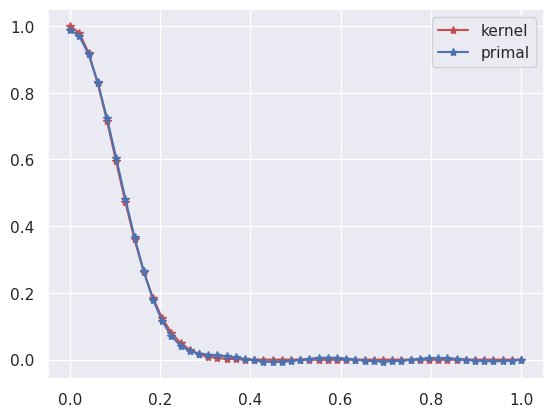

In [48]:
### domain bound U=1!!!
m_order = 16
l_scale = 0.1
fmap, dtype = prepare_fmap(RBFFeature(l_scale=l_scale), m_order=m_order, is_quant=False)
#fmap = partial(ff_feature_map, M=m_order, lscale=l_scale)
x2 = 0.0
x1 = jnp.linspace(0, 1, 50)
rbf_res = []
rbf_primal_res = []
for x in x1:
    rbf_res.append(rbf_kernel(x, x2, l_scale).item())
    rbf_primal_res.append(rbf_kernel_primal(x, x2, fmap).item())

plt.plot(x1, rbf_res, '-*r', label='kernel')
plt.plot(x1, rbf_primal_res, '-*b', label='primal')
plt.legend()
plt.grid(True)

## GP Baseline:

In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
import sklearn.gaussian_process.kernels as gp_kern

DATA_NAME = 'yacht'
QUANT, SEED = False, 13
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' #'std' / 'minmax'

FINAL_D = 6

x, x_test, y, y_test, n_samples, d_dim = get_data(DATA_NAME, FINAL_D, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(np.array, [x, x_test, y, y_test])

kernel = (
    gp_kern.RBF(length_scale=1, length_scale_bounds=(1e-3, 1e3)) 
    + gp_kern.WhiteKernel(noise_level=1, noise_level_bounds=(1e-10, 1e3))
)

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=0.5,
    random_state=0,
    n_restarts_optimizer=15,
)
model.fit(x, y)

pred_mean, pred_std = model.predict(x, return_std=True)
rmse_train = rmse(y, pred_mean)
pred_mean, pred_std = model.predict(x_test, return_std=True)
rmse_test = rmse(y_test, pred_mean)
nll_test = nll(pred_mean, pred_std**2, y_test)
print(f"RMSE Train: {rmse_train}; RMSE Test: {rmse_test}; NLL Test: {nll_test}")

NameError: name 'get_data' is not defined

## CPD Model:

In [ ]:
def l2_loss_only(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_shape):
    w_ten = vec2ten3(w_vec, *w_shape)
    scores = predict_score(x, kd, w_ten, fmap)
    return 0.5*jnp.sum((y - scores)**2)

def l2_reg_only(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_shape):
    return 0.5*(w_vec * w_vec).sum()

def cpd_als_map_estimate(x, x_test, y, y_test, fmap, m_order, rank, gamma_w, beta_e, n_epoch, seed, dtype):
    w_ten, kd = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=seed, dtype=dtype)

    grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
    grad_w_loss_only = jit(grad(l2_loss_only, argnums=0), static_argnums=(4, 7))
    grad_w_reg_only = jit(grad(l2_reg_only, argnums=0), static_argnums=(4, 7))
    
    fw_hadamard, ww_hadamard = get_fw_hadamard_mtx(x, kd, w_ten, fmap), get_ww_hadamard_mtx(w_ten)
    res_dict = defaultdict(list)
    for ep in range(n_epoch):
        w_ten, fw_hadamard, ww_hadamard = update_weights(
            x, y, gamma_w, beta_e, kd, w_ten, fmap, 
            fw_hadamard, ww_hadamard, pinv=False, ww_reg=False,
        )
        try:
            check_nan(w_ten)
        except NaNFoundError as e:
            raise
        w_vec = ten3tovec(w_ten)
        res_dict['loss_list'].append(l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item())
        res_dict['rmse_train_list'].append(rmse(y, predict_score(x, kd, w_ten, fmap)))
        res_dict['rmse_test_list'].append(rmse(y_test, predict_score(x_test, kd, w_ten, fmap)))
        res_dict['w_norm_list'].append(norm_frob(w_ten))
        
        res_dict['loss_grad_map_list'].append(norm_frob(grad_w(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)))
        res_dict['loss_only_grad_map_list'].append(norm_frob(grad_w_loss_only(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)))
        res_dict['reg_only_grad_map_list'].append(norm_frob(grad_w_reg_only(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)))
    return w_ten, res_dict

DATA_NAME = 'yacht'
FMAP = PPFeature() #PPNFeature()
QUANT, SEED = False, 13
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' #'std' / 'minmax'

FINAL_D = 6
RANK, M_ORDER, N_EPOCH = 10, 4, 100
BETA_E = 1.0
GAMMA_W = 0.1

x, x_test, y, y_test, n_samples, d_dim = get_data(DATA_NAME, FINAL_D, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, y = jnp.array(x), jnp.array(y)
fmap, dtype = prepare_fmap(FMAP, M_ORDER, QUANT)
print(f"#Model params P = {np.prod((d_dim, M_ORDER, RANK))} (FP32)")

w_ten, res_dict = cpd_als_map_estimate(x, x_test, y, y_test, fmap, M_ORDER, RANK, GAMMA_W, BETA_E, N_EPOCH, SEED, dtype)
print(f"\nW Frob. norm = {norm_frob(w_ten)}, W shape = {w_ten.shape}")
plot_metrics(res_dict)

In [ ]:
DATA_NAME = 'yacht'
FMAP = PPFeature() #PPNFeature()
QUANT, SEED = False, 13
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' #'std' / 'minmax'

FINAL_D = 6
N_EPOCH = 10
N_EPOCH_GLOBAL = 10
BETA_E_SAMPLES = 10
BETA_E = None
GAMMA_W = None

params = dict(
    rank=[2, 4, 8, 16, 32],
    m_order=[2, 3, 4, 5, 6],
    hess_mode=['block_diag', 'full'],
    Fmap=[PPFeature(), PPNFeature(), RBFFeature()]
)

grid, param_names = full_grid(params)

res_dict = dict()
for i, vals in enumerate(grid):
    print(f'{i}/{len(grid)}')
    rank, m_order, hess_mode, FMAP = vals
    try:
        x, x_test, y, y_test, n_samples, d_dim = get_data(DATA_NAME, FINAL_D, TRANSFORM_X, TRANSFORM_Y, SCALER)
        x, y = jnp.array(x), jnp.array(y)
        fmap, dtype = prepare_fmap(FMAP, m_order, QUANT)
        print(f"#Model params P = {np.prod((d_dim, m_order, rank))} (FP32)")

        w_ten, kd, cov_mtx, cholesky_mtx, beta_e, _ = cpd_model_als(
            x, x_test, y, y_test, fmap, 
            m_order, rank, N_EPOCH, 
            GAMMA_W, BETA_E,
            N_EPOCH_GLOBAL,
            hess_mode, 
            SEED, dtype,
            BETA_E_SAMPLES,
            ww_reg=False,
        )

        nll_test = nll(
            predict_score(x_test, kd, w_ten, fmap),
            predict_std(w_ten, cholesky_mtx, kd, x_test, fmap, beta_e, pred_dist_n_samples=100)**2,
            jnp.array(y_test),
        )
        rmse_test = rmse(y_test, predict_score(x_test, kd, w_ten, fmap))
        res_dict[vals] = (nll_test, rmse_test, w_ten.shape)

    except Exception as e:
        res_dict[vals] = (None, None, None)
        #print(e)

ddd = defaultdict(list)
for k, v in res_dict.items():
    rank, m_order, hess_mode, FMAP = k
    if v[0] is not None:
        nll_test, rmse_test, (d, I, R) = v
    else:
        nll_test, rmse_test, (d, I, R) = None, None, (None, None, None)
    ddd['m_order'].append(m_order)
    ddd['hess_mode'].append(hess_mode)
    ddd['nll_test'].append(nll_test)
    ddd['rmse_test'].append(rmse_test)
    ddd['D'].append(d)
    ddd['final_rank'].append(R)
    ddd['rank'].append(rank)

i = 2
display(pd.DataFrame(ddd)[i*50:i*50 + 50].sort_values(by='nll_test'))

In [ ]:
DATA_NAME = 'yacht'
FMAP = PPFeature() #PPNFeature()
QUANT, SEED = False, 13
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' #'std' / 'minmax'

FINAL_D = 6
RANK, M_ORDER, N_EPOCH = 4, 4, 10#16, 4, 10
N_EPOCH_GLOBAL = 10
BETA_E_SAMPLES = 30
BETA_E = None
GAMMA_W = None
HESS_MODE = 'block_diag' # 'full' / 'block_diag'

x, x_test, y, y_test, n_samples, d_dim = get_data(DATA_NAME, FINAL_D, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, y = jnp.array(x), jnp.array(y)
fmap, dtype = prepare_fmap(FMAP, M_ORDER, QUANT)
print(f"#Model params P = {np.prod((d_dim, M_ORDER, RANK))} (FP32)")

w_ten, kd, cov_mtx, cholesky_mtx, beta_e, res_dict = cpd_model_als(
    x, x_test, y, y_test, fmap, 
    M_ORDER, RANK, N_EPOCH, 
    GAMMA_W, BETA_E,
    N_EPOCH_GLOBAL,
    HESS_MODE, 
    SEED, dtype,
    BETA_E_SAMPLES,
    ww_reg=False,
)
print(f"\nW Frob. norm = {norm_frob(w_ten)}, W shape = {w_ten.shape}")
print('Test NLL: ',
    nll(
        predict_score(x_test, kd, w_ten, fmap),
        predict_std(w_ten, cholesky_mtx, kd, x_test, fmap, beta_e, pred_dist_n_samples=100)**2,
        jnp.array(y_test),
    )
)

plot_metrics(res_dict)
plot_mtx(cov_mtx, 'Covariance matrix')

In [ ]:
def cpd_model_grad(
    x, x_test, y, y_test, fmap, 
    m_order, rank, n_epoch, 
    gamma_w, beta_e,
    n_epoch_global,
    hess_mode, 
    seed, dtype,
    beta_e_samples,
    batch_size, lr,
):
    beta_e_upd = beta_e is None
    gamma_w_upd = gamma_w is None
    if beta_e_upd:
        cn, dn = 1, 1
        beta_e = cn / dn 
    if gamma_w_upd:
        an, bn = 1, 1
        gamma_w = an / bn
    alpha = gamma_w / beta_e

    w_ten, kd = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=seed, dtype=dtype)
    w_ten *= 0.1

    grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
    res_dict = defaultdict(list)
    for g_ep in range(n_epoch_global):
        print(alpha, gamma_w, beta_e)
        m = jnp.zeros_like(ten3tovec(w_ten))
        v = jnp.zeros_like(m)
        t = 0  # Time step
        for ep in range(n_epoch):
            w_vec = ten3tovec(w_ten)
            for x_batch, y_batch in get_batches(x, y, batch_size=batch_size):
                dw = grad_w(w_vec, kd, x_batch, y_batch, fmap, gamma_w, beta_e, w_ten.shape)
                w_vec, m, v, t = adam_update(w_vec, dw, m, v, t, lr)
            w_ten = vec2ten3(w_vec, *w_ten.shape)
            try:
                check_nan(w_ten)
            except NaNFoundError as e:
                raise

            res_dict['loss_list'].append(l2_gb_loss(ten3tovec(w_ten), kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item())
            res_dict['rmse_train_list'].append(rmse(y, predict_score(x, kd, w_ten, fmap)))
            res_dict['rmse_test_list'].append(rmse(y_test, predict_score(x_test, kd, w_ten, fmap)))
            res_dict['w_norm_list'].append(norm_frob(w_ten))

        w_cov = hess_full(w_ten, kd, x, y, fmap, gamma_w, beta_e, mode=hess_mode)
        try:
            w_cov = np.linalg.pinv(w_cov)
        except np.linalg.LinAlgError as err:
            print(norm_frob(w_cov))
            raise
        try:
            w_cholesky = np.linalg.cholesky(w_cov)
        except np.linalg.LinAlgError as err:
            print(np.sort(np.linalg.eigvals(w_cov)))
            raise

        if beta_e_upd:
            cn, dn, beta_e = update_beta_e(cn, dn, w_cholesky, w_ten, w_ten.shape, kd, fmap, x, y, beta_e_samples)
        if gamma_w_upd:
            an, bn, gamma_w = update_gamma_w(an, bn, w_cov, ten3tovec(w_ten))

        alpha = gamma_w / beta_e

    return w_ten, kd, w_cov, w_cholesky, beta_e, res_dict

In [ ]:
from source.evaluation import l2_gb_loss
from source.optimization import gd_update

def l2_loss_only(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_shape):
    w_ten = vec2ten3(w_vec, *w_shape)
    scores = predict_score(x, kd, w_ten, fmap)
    return 0.5*jnp.sum((y - scores)**2)

def l2_reg_only(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_shape):
    return 0.5*(w_vec * w_vec).sum()

def cpd_grad_map_estimate(x, x_test, y, y_test, fmap, m_order, rank, lr, bs, gamma_w, beta_e, n_epoch, seed, dtype):
    w_ten, kd = init_weights(m_order, rank, x.shape[1], q_base=None, init_type=None, seed=seed, dtype=dtype)
    w_ten *= 0.3

    grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))
    grad_w_loss_only = jit(grad(l2_loss_only, argnums=0), static_argnums=(4, 7))
    grad_w_reg_only = jit(grad(l2_reg_only, argnums=0), static_argnums=(4, 7))
    m = jnp.zeros_like(ten3tovec(w_ten))
    v = jnp.zeros_like(m)
    t = 0  # Time step
    
    res_dict = defaultdict(list)
    for ep in range(n_epoch):
        w_vec = ten3tovec(w_ten)
        for x_batch, y_batch in get_batches(x, y, batch_size=bs):
            dw = grad_w(w_vec, kd, x_batch, y_batch, fmap, gamma_w, beta_e, w_ten.shape)
            w_vec, m, v, t = adam_update(w_vec, dw, m, v, t, lr)
            w_vec = gd_update(w_vec, dw, lr)
        #dw = grad_w(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)
        #w_vec = gd_update(w_vec, dw, lr)
        w_ten = vec2ten3(w_vec, *w_ten.shape)
        res_dict['loss_list'].append(l2_gb_loss(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape).item())
        res_dict['rmse_train_list'].append(rmse(y, predict_score(x, kd, w_ten, fmap)))
        res_dict['rmse_test_list'].append(rmse(y_test, predict_score(x_test, kd, w_ten, fmap)))
        res_dict['w_norm_list'].append(norm_frob(w_ten))
        
        res_dict['loss_grad_map_list'].append(norm_frob(grad_w(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)))
        res_dict['loss_only_grad_map_list'].append(norm_frob(grad_w_loss_only(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)))
        res_dict['reg_only_grad_map_list'].append(norm_frob(grad_w_reg_only(w_vec, kd, x, y, fmap, gamma_w, beta_e, w_ten.shape)))
    return w_ten, res_dict

DATA_NAME = 'yacht'
FMAP = PPFeature() #PPNFeature()
QUANT, SEED = False, 13
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' #'std' / 'minmax'

FINAL_D = 6
RANK, M_ORDER, N_EPOCH = 8, 4, 1000
BETA_E = 1.0
GAMMA_W = 1.0
LR = 1e-4
BS = 256

x, x_test, y, y_test, n_samples, d_dim = get_data(DATA_NAME, FINAL_D, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, y = jnp.array(x), jnp.array(y)
fmap, dtype = prepare_fmap(FMAP, M_ORDER, QUANT)
print(f"#Model params P = {np.prod((d_dim, M_ORDER, RANK))} (FP32)")

w_ten, res_dict = cpd_grad_map_estimate(x, x_test, y, y_test, fmap, M_ORDER, RANK, LR, BS, GAMMA_W, BETA_E, N_EPOCH, SEED, dtype)
print(f"\nW Frob. norm = {norm_frob(w_ten)}, W shape = {w_ten.shape}")
plot_metrics(res_dict)

In [ ]:
DATA_NAME = 'yacht'
FMAP = PPFeature() #PPNFeature()
QUANT, SEED = False, 13
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' #'std' / 'minmax'

FINAL_D = 6
N_EPOCH = 300
N_EPOCH_GLOBAL = 10
BETA_E_SAMPLES = 10
BETA_E = None
GAMMA_W = None
BATCH_SIZE, LR = 256, 5e-3

params = dict(
    rank=[2, 4, 8, 16, 32],
    m_order=[2, 3, 4, 5, 6],
    hess_mode=['block_diag', 'full'],
    Fmap=[PPFeature(), PPNFeature(), RBFFeature()]
)

grid, param_names = full_grid(params)

res_dict = dict()
for i, vals in enumerate(grid):
    print(f'{i}/{len(grid)}')
    rank, m_order, hess_mode, FMAP = vals
    try:
        x, x_test, y, y_test, n_samples, d_dim = get_data(DATA_NAME, FINAL_D, TRANSFORM_X, TRANSFORM_Y, SCALER)
        x, y = jnp.array(x), jnp.array(y)
        fmap, dtype = prepare_fmap(FMAP, m_order, QUANT)
        print(f"#Model params P = {np.prod((d_dim, m_order, rank))} (FP32)")

        w_ten, kd, cov_mtx, cholesky_mtx, beta_e, _ = cpd_model_grad(
            x, x_test, y, y_test, fmap, 
            m_order, rank, N_EPOCH, 
            GAMMA_W, BETA_E,
            N_EPOCH_GLOBAL,
            hess_mode, 
            SEED, dtype,
            BETA_E_SAMPLES,
            BATCH_SIZE, LR,
        )

        nll_test = nll(
            predict_score(x_test, kd, w_ten, fmap),
            predict_std(w_ten, cholesky_mtx, kd, x_test, fmap, beta_e, pred_dist_n_samples=100)**2,
            jnp.array(y_test),
        )
        rmse_test = rmse(y_test, predict_score(x_test, kd, w_ten, fmap))
        res_dict[vals] = (nll_test, rmse_test)

    except Exception as e:
        res_dict[vals] = (None, None)
        #print(e)

In [ ]:
DATA_NAME = 'yacht'
FMAP = PPFeature() #PPNFeature()
QUANT, SEED = False, 13
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std' #'std' / 'minmax'

FINAL_D = 6
RANK, M_ORDER, N_EPOCH = 16, 4, 100
N_EPOCH_GLOBAL = 10
BETA_E_SAMPLES = 30
BETA_E = None
GAMMA_W = None
BATCH_SIZE, LR = 512, 1e-3
HESS_MODE = 'block_diag' # 'full' / 'block_diag'

x, x_test, y, y_test, n_samples, d_dim = get_data(DATA_NAME, FINAL_D, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, y = jnp.array(x), jnp.array(y)
fmap, dtype = prepare_fmap(FMAP, M_ORDER, QUANT)
print(f"#Model params P = {np.prod((d_dim, M_ORDER, RANK))} (FP32)")

w_ten, kd, cov_mtx, cholesky_mtx, beta_e, res_dict = cpd_model_grad(
    x, x_test, y, y_test, fmap, 
    M_ORDER, RANK, N_EPOCH, 
    GAMMA_W, BETA_E,
    N_EPOCH_GLOBAL,
    HESS_MODE, 
    SEED, dtype,
    BETA_E_SAMPLES,
    BATCH_SIZE, LR,
)

print(f"\nW Frob. norm = {norm_frob(w_ten)}, W shape = {w_ten.shape}")
print('Test NLL: ',
    nll(
        predict_score(x_test, kd, w_ten, fmap),
        predict_std(w_ten, cholesky_mtx, kd, x_test, fmap, beta_e, pred_dist_n_samples=100)**2,
        jnp.array(y_test),
    )
)

plot_metrics(res_dict)
plot_mtx(cov_mtx, 'Covariance matrix')